<a href="https://colab.research.google.com/github/SeiMiyo06/Mapas_Delictivos/blob/main/Mapas_municipales_delitos_1223.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### José Miguel De Jesús Vázquez JMDJV
### Creación de mapas de incidencia delictiva U12 Meses
### Nivel Estado - Municipio

In [ ]:
!pip install geopandas
!pip install descartes
!pip install folium matplotlib mapclassify

# Para manipulación de imagenes
from PIL import Image

In [ ]:
from geopandas import GeoSeries
from shapely.geometry import Polygon

In [ ]:
!pip install fiona
import fiona
fiona.drvsupport.supported_drivers['libkml'] = 'rw'
fiona.drvsupport.supported_drivers['LIBKML'] = 'rw'

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Se importan las librerias necesarias
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt

<Axes: >

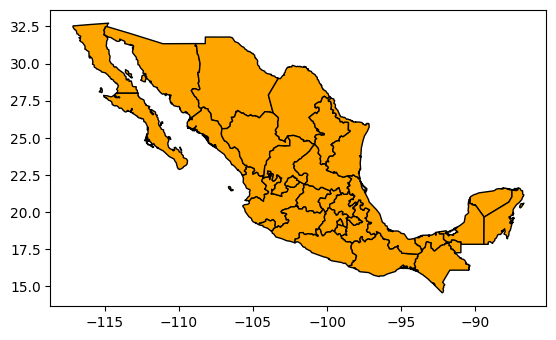

In [ ]:
# Mapa a nivel Estado

mexico_edo = gpd.read_file('/content/drive/MyDrive/Bases_de_datos/México_Estados.shx')
mexico_edo.plot(color = 'orange', edgecolor='k')

<Axes: >

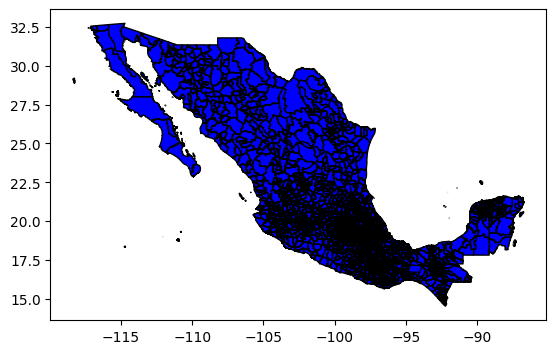

In [ ]:
# Creacion de base de datos geograficos de México por municipio.
mexico_mun = gpd.read_file('/content/drive/MyDrive/Bases_de_datos/mexico.json')
mexico_mun.plot(color = 'blue', edgecolor='k')

In [ ]:
mexico_mun['KEY_MUN']=mexico_mun.CVEGEO.astype('str').str.zfill(6)
mexico_mun.head(5)

,CVEGEO,CVE_ENT,CVE_MUN,NOM_ENT,NOM_MUN,Area,PERIMETER,COV_,COV_ID,geometry,KEY_MUN
0,01001,01,001,Aguascalientes,Aguascalientes,116635.924759,256.631025,0,1,"POLYGON ((-102.10641 22.06035, -102.10368 22.0...",001001
1,01002,01,002,Aguascalientes,Asientos,54337.426603,192.096428,1,2,"POLYGON ((-102.05189 22.29144, -102.05121 22.2...",001002
2,01003,01,003,Aguascalientes,Calvillo,92335.783229,171.636168,2,3,"POLYGON ((-102.68569 22.09963, -102.69087 22.0...",001003
3,01004,01,004,Aguascalientes,Cosío,12838.354454,73.352682,3,4,"POLYGON ((-102.28787 22.41649, -102.28753 22.4...",001004
4,01005,01,005,Aguascalientes,Jesús María,49989.509158,163.500810,4,5,"POLYGON ((-102.33568 22.05067, -102.33348 22.0...",001005


In [ ]:
# Dado que no se cuenta con la descripcion de los estados se crea un orden y luego se asignan valores

list_edo=[]
for i in range(1,33):
  list_edo.append(str(i).zfill(3))

edo = pd.DataFrame(list_edo, columns=['CVE_ENT'])

mexico_edo2 = mexico_edo.merge(edo, left_index=True, right_index=True)

In [ ]:
# Diccionario de orden - claves de estados

dict_edo = {'001':'002',
            '002':'003',
            '003':'018',
            '004':'014',
            '005':'001',
            '006':'011',
            '007':'022',
            '008':'013',
            '009':'016',
            '010':'015',
            '011':'009',
            '012':'006',
            '013':'017',
            '014':'031',
            '015':'004',
            '016':'021',
            '017':'023',
            '018':'029',
            '019':'012',
            '020':'020',
            '021':'027',
            '022':'007',
            '023':'026',
            '024':'008',
            '025':'005',
            '026':'025',
            '027':'010',
            '028':'032',
            '029':'024',
            '030':'019',
            '031':'028',
            '032':'030'}

edos_correctos = pd.DataFrame(list(dict_edo.items()), columns=['CVE_ENT', 'CVE_ENT2'])
edos_correctos

mexico_edo3 = mexico_edo2.merge(edos_correctos, left_index=True, right_index=True)
mexico_edo4 = mexico_edo3.loc[:, ['CVE_ENT2', 'geometry']]
mexico_edo4.columns=['KEY_EDO', 'geometry']
# mexico_edo4

In [ ]:
mexico_edo4['KEY_EDO'] = mexico_edo4.KEY_EDO.astype('str').str.zfill(3)
mexico_edo4.head(5)

,KEY_EDO,geometry
0,002,"MULTIPOLYGON (((-113.13972 29.01778, -113.2405..."
1,003,"MULTIPOLYGON (((-111.20612 25.80278, -111.2302..."
2,018,"MULTIPOLYGON (((-106.62108 21.56531, -106.6475..."
3,014,"POLYGON ((-101.52490 21.85664, -101.58830 21.7..."
4,001,"POLYGON ((-101.84620 22.01176, -101.96530 21.8..."


In [ ]:
# Creacion de base de datos de incidencia delictiva.
# Fuente - Secretariado Ejecutivo del Sistema Nacional de Seguridad Pública

secre=pd.read_csv('/content/drive/MyDrive/Bases_de_datos/IDM_NM_dic23.csv', encoding='latin-1')
secre.columns=['AÑO', 'CVE_ENT', 'NOM_ENT', 'CVE_MUN', 'NOM_MUN', 'BIEN', 'TIP_DEL', 'SUB_DEL', 'MOD',
               'ENE', 'FEB', 'MZO', 'ABR', 'MAY', 'JUN', 'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
secre.head(5)

,AÑO,CVE_ENT,NOM_ENT,CVE_MUN,NOM_MUN,BIEN,TIP_DEL,SUB_DEL,MOD,ENE,...,MZO,ABR,MAY,JUN,JUL,AGO,SEP,OCT,NOV,DIC
0,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,2,...,1,1,0,1,1,0,2,1,0,1
1,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,...,0,0,0,1,0,1,0,0,0,0
2,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,...,1,1,3,2,0,1,2,0,0,0
3,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,1,...,0,1,0,0,0,0,0,0,0,0
4,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
# Seleccionando y separando los conjuntos de datos por años
años = [2022,2023]
delitos = ['Homicidio doloso',
           'Lesiones dolosas',
           'Secuestro',
           'Fraude',
           'Extorsión',
           'Amenazas',
           'Robo de vehículo automotor',
           'Robo a transportista',
           'Robo de autopartes']

modalidades = ['Con arma de fuego', 'Con arma blanca', 'Con otro elemento','No especificado',
               'Secuestro extorsivo', 'Secuestro con calidad de rehén','Secuestro para causar daño', 'Secuestro exprés','Otro tipo de secuestros',
               'Fraude',
               'Extorsión',
               'Amenazas',
               'Robo de coche de 4 ruedas Con violencia','Robo de coche de 4 ruedas Sin violencia', 'Robo de motocicleta Con violencia', 'Robo de motocicleta Sin violencia',
               'Con violencia','Sin violencia',
               'Con violencia','Sin violencia']

secre2022 = secre[secre.SUB_DEL.isin(delitos)  &
                  secre.AÑO.isin([2022]) &
                  secre.MOD.isin(modalidades)
                  ]

secre2023 = secre[secre.SUB_DEL.isin(delitos)  &
                  secre.AÑO.isin([2023]) &
                  secre.MOD.isin(modalidades)
                  ]
secre2022.columns=['AÑO', 'CVE_ENT', 'NOM_ENT', 'CVE_MUN', 'NOM_MUN', 'BIEN', 'TIP_DEL', 'SUB_DEL', 'MOD',
                   'ENE_2022', 'FEB_2022', 'MZO_2022', 'ABR_2022', 'MAY_2022', 'JUN_2022', 'JUL_2022', 'AGO_2022', 'SEP_2022', 'OCT_2022', 'NOV_2022', 'DIC_2022']

secre2023.columns=['AÑO', 'CVE_ENT', 'NOM_ENT', 'CVE_MUN', 'NOM_MUN', 'BIEN', 'TIP_DEL', 'SUB_DEL', 'MOD',
                   'ENE_2023', 'FEB_2023', 'MZO_2023', 'ABR_2023', 'MAY_2023', 'JUN_2023', 'JUL_2023', 'AGO_2023', 'SEP_2023', 'OCT_2023', 'NOV_2023', 'DIC_2023']

secre2023.head(5)

,AÑO,CVE_ENT,NOM_ENT,CVE_MUN,NOM_MUN,BIEN,TIP_DEL,SUB_DEL,MOD,ENE_2023,...,MZO_2023,ABR_2023,MAY_2023,JUN_2023,JUL_2023,AGO_2023,SEP_2023,OCT_2023,NOV_2023,DIC_2023
1832404,2023,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,1,...,2,1,1,1,1,3,1,1,0,2
1832405,2023,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,2,...,0,1,0,2,0,3,1,0,3,0
1832406,2023,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,1,...,1,0,0,3,0,0,1,1,2,1
1832407,2023,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,0,...,0,0,0,0,0,0,0,0,0,0
1832413,2023,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Lesiones,Lesiones dolosas,Con arma de fuego,4,...,4,2,1,0,1,4,3,6,0,3


In [ ]:
# Para evitar duplicados
secre2022.drop(['AÑO'], axis=1, inplace=True)

secre_01 = pd.merge(left=secre2023,
                    right=secre2022,
                    how='left',
                    left_on=['CVE_ENT','NOM_ENT', 'CVE_MUN',	'NOM_MUN', 'BIEN',	'TIP_DEL',	'SUB_DEL',	'MOD'],
                    right_on=['CVE_ENT','NOM_ENT', 'CVE_MUN',	'NOM_MUN', 'BIEN',	'TIP_DEL',	'SUB_DEL',	'MOD']
                    )
secre_01['KEY_EDO']=secre_01.CVE_ENT

<ipython-input-80-22865359666e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  secre2022.drop(['AÑO'], axis=1, inplace=True)


In [ ]:
# Cambiando el tipo de dato de CVE_MUN a caracter (no numérico)
secre_01['CVE_MUN'] = secre_01['CVE_MUN'].astype('object')
secre_01.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 59592 entries, 0 to 59591
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AÑO       59592 non-null  int64  
 1   CVE_ENT   59592 non-null  int64  
 2   NOM_ENT   59592 non-null  object 
 3   CVE_MUN   59592 non-null  object 
 4   NOM_MUN   59592 non-null  object 
 5   BIEN      59592 non-null  object 
 6   TIP_DEL   59592 non-null  object 
 7   SUB_DEL   59592 non-null  object 
 8   MOD       59592 non-null  object 
 9   ENE_2023  59592 non-null  int64  
 10  FEB_2023  59592 non-null  int64  
 11  MZO_2023  59592 non-null  int64  
 12  ABR_2023  59592 non-null  int64  
 13  MAY_2023  59592 non-null  int64  
 14  JUN_2023  59592 non-null  int64  
 15  JUL_2023  59592 non-null  int64  
 16  AGO_2023  59592 non-null  int64  
 17  SEP_2023  59592 non-null  int64  
 18  OCT_2023  59592 non-null  int64  
 19  NOV_2023  59592 non-null  int64  
 20  DIC_2023  59592 non-null  in

In [ ]:
secre_t = secre_01.loc[:,['CVE_ENT','NOM_ENT','CVE_MUN','NOM_MUN', 'BIEN', 'TIP_DEL', 'SUB_DEL', 'MOD',
                'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023',
                'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022']].groupby(by = ['CVE_ENT', 'CVE_MUN','NOM_ENT','NOM_MUN','SUB_DEL', 'MOD'], as_index=True).sum().reset_index()

secre_t['KEY_EDO']=secre_t.CVE_ENT.astype('str').str.zfill(3)
secre_t['KEY_MUN']=secre_t.CVE_MUN.astype('str').str.zfill(6)

secre_t.head(5)

<ipython-input-82-9303d1500b2a>:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022']].groupby(by = ['CVE_ENT', 'CVE_MUN','NOM_ENT','NOM_MUN','SUB_DEL', 'MOD'], as_index=True).sum().reset_index()


,CVE_ENT,CVE_MUN,NOM_ENT,NOM_MUN,SUB_DEL,MOD,ENE_2023,FEB_2023,MZO_2023,ABR_2023,...,MAY_2022,JUN_2022,JUL_2022,AGO_2022,SEP_2022,OCT_2022,NOV_2022,DIC_2022,KEY_EDO,KEY_MUN
0,1,1001,Aguascalientes,Aguascalientes,Amenazas,Amenazas,196,253,317,242,...,288.0,276.0,266.0,293.0,253.0,267.0,211.0,193.0,001,001001
1,1,1001,Aguascalientes,Aguascalientes,Extorsión,Extorsión,8,4,4,2,...,7.0,6.0,8.0,6.0,12.0,5.0,9.0,7.0,001,001001
2,1,1001,Aguascalientes,Aguascalientes,Fraude,Fraude,198,155,229,187,...,168.0,225.0,197.0,240.0,204.0,183.0,184.0,174.0,001,001001
3,1,1001,Aguascalientes,Aguascalientes,Homicidio doloso,Con arma blanca,2,1,0,1,...,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,001,001001
4,1,1001,Aguascalientes,Aguascalientes,Homicidio doloso,Con arma de fuego,1,2,2,1,...,0.0,3.0,0.0,2.0,5.0,1.0,1.0,1.0,001,001001


In [ ]:
secre_edot = secre_t.groupby(by = ['CVE_ENT', 'NOM_ENT','SUB_DEL', 'MOD','KEY_EDO'], as_index=True).sum().reset_index()
secre_edot #192 x 20 registers

secre_munt = secre_t.groupby(by = ['CVE_ENT', 'NOM_ENT','CVE_MUN', 'NOM_MUN','SUB_DEL', 'MOD', 'KEY_MUN'], as_index=True).sum().reset_index()
secre_munt #14,898 x 21 registers

secre_munt.head(3)

<ipython-input-83-5296a7714f77>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  secre_edot = secre_t.groupby(by = ['CVE_ENT', 'NOM_ENT','SUB_DEL', 'MOD','KEY_EDO'], as_index=True).sum().reset_index()
<ipython-input-83-5296a7714f77>:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  secre_munt = secre_t.groupby(by = ['CVE_ENT', 'NOM_ENT','CVE_MUN', 'NOM_MUN','SUB_DEL', 'MOD', 'KEY_MUN'], as_index=True).sum().reset_index()


,CVE_ENT,NOM_ENT,CVE_MUN,NOM_MUN,SUB_DEL,MOD,KEY_MUN,ENE_2023,FEB_2023,MZO_2023,...,MZO_2022,ABR_2022,MAY_2022,JUN_2022,JUL_2022,AGO_2022,SEP_2022,OCT_2022,NOV_2022,DIC_2022
0,1,Aguascalientes,1001,Aguascalientes,Amenazas,Amenazas,001001,196,253,317,...,295.0,265.0,288.0,276.0,266.0,293.0,253.0,267.0,211.0,193.0
1,1,Aguascalientes,1001,Aguascalientes,Extorsión,Extorsión,001001,8,4,4,...,3.0,6.0,7.0,6.0,8.0,6.0,12.0,5.0,9.0,7.0
2,1,Aguascalientes,1001,Aguascalientes,Fraude,Fraude,001001,198,155,229,...,171.0,158.0,168.0,225.0,197.0,240.0,204.0,183.0,184.0,174.0


In [ ]:
secre_munt['SUB_DEL'].unique()

array(['Amenazas', 'Extorsión', 'Fraude', 'Homicidio doloso',
       'Lesiones dolosas', 'Robo a transportista', 'Robo de autopartes',
       'Robo de vehículo automotor', 'Secuestro'], dtype=object)

In [ ]:
secre_edot['U12'] = secre_edot['DIC_2023']+secre_edot['NOV_2023']+secre_edot['OCT_2023']+secre_edot['SEP_2023']+secre_edot['AGO_2023']+secre_edot['JUL_2023']+secre_edot['JUN_2023']+secre_edot['MAY_2023']+secre_edot['ABR_2023']+secre_edot['MZO_2023']+secre_edot['FEB_2023']+secre_edot['ENE_2023']
secre_edot['PER_V'] = secre_edot['ENE_2023'] + secre_edot['FEB_2023']+secre_edot['MZO_2023']+secre_edot['ABR_2023']+secre_edot['MAY_2023']+secre_edot['JUN_2023']+secre_edot['JUL_2023']+secre_edot['AGO_2023']+secre_edot['SEP_2023']+secre_edot['OCT_2023']+secre_edot['NOV_2023']+secre_edot['DIC_2023']
secre_edot['PER_A'] = secre_edot['ENE_2022'] + secre_edot['FEB_2022']+secre_edot['MZO_2022']+secre_edot['ABR_2022']+secre_edot['MAY_2022']+secre_edot['JUN_2022']+secre_edot['JUL_2022']+secre_edot['AGO_2022']+secre_edot['SEP_2022']+secre_edot['OCT_2022']+secre_edot['NOV_2022']+secre_edot['DIC_2022']

secre_munt['U12'] = secre_munt['DIC_2023']+secre_munt['NOV_2023']+secre_munt['OCT_2023']+secre_munt['SEP_2023']+secre_munt['AGO_2023']+secre_munt['JUL_2023']+secre_munt['JUN_2023'] + secre_munt['MAY_2023']+secre_munt['ABR_2023']+secre_munt['MZO_2023']+secre_munt['FEB_2023']+secre_munt['ENE_2023']
secre_munt['PER_V'] = secre_munt['ENE_2023'] + secre_munt['FEB_2023']+secre_munt['MZO_2023']+secre_munt['ABR_2023']+secre_munt['MAY_2023']+secre_munt['JUN_2023']+secre_munt['JUL_2023']+secre_munt['AGO_2023']+secre_munt['SEP_2023']+secre_munt['OCT_2023']+secre_munt['NOV_2023']+secre_munt['DIC_2023']
secre_munt['PER_A'] = secre_munt['ENE_2022'] + secre_munt['FEB_2022']+secre_munt['MZO_2022']+secre_munt['ABR_2022']+secre_munt['MAY_2022']+secre_munt['JUN_2022']+secre_munt['JUL_2022']+secre_munt['AGO_2022']+secre_munt['SEP_2022']+secre_munt['OCT_2022']+secre_munt['NOV_2022']+secre_munt['DIC_2022']


In [ ]:
# Creacion de base de datos de Censo 2020 INEGI
# Fuente - INEGI 2020
# Tipo de configuración para guardar acentos y caracteres especiales?

inegi=pd.read_csv('/content/drive/MyDrive/Bases_de_datos/conjunto_de_datos_iter_00CSV20.csv', encoding='utf-8')
inegi.head(5)

<ipython-input-86-ff2e31d7a4ed>:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  inegi=pd.read_csv('/content/drive/MyDrive/Bases_de_datos/conjunto_de_datos_iter_00CSV20.csv', encoding='utf-8')


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,...,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,126014024,...,30775898,18307193,15211306,6616141,4047100,1788552,3170894,15108204,852871,*
1,0,Total nacional,0,Total nacional,9998,Localidades de una vivienda,NaN,NaN,NaN,250354,...,47005,8385,18981,1732,1113,12775,14143,51293,7154,*
2,0,Total nacional,0,Total nacional,9999,Localidades de dos viviendas,NaN,NaN,NaN,147125,...,25581,5027,11306,971,708,8247,10065,29741,5283,*
3,1,Aguascalientes,0,Total de la entidad Aguascalientes,0,Total de la Entidad,NaN,NaN,NaN,1425607,...,359895,236003,174089,98724,70126,6021,15323,128996,1711,*
4,1,Aguascalientes,0,Total de la entidad Aguascalientes,9998,Localidades de una vivienda,NaN,NaN,NaN,3697,...,732,205,212,48,41,39,62,530,20,*


In [ ]:
# Seleccionando datos de conjunto de datos INEGI
# Trabajar con cifras a nivel municipal

inegi2 = inegi.loc[:, ['ENTIDAD', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'NOM_ENT', 'POBTOT']]
inegi2.columns=['CVE_ENT', 'CVE_MUN', 'NOM_MUN', 'CVE_LOC', 'NOM_LOC', 'NOM_ENT','POBTOT']

inegi_edo = inegi2[inegi2['NOM_LOC'] == 'Total de la Entidad']
inegi_mun = inegi2[inegi2['CVE_LOC'] == 0]

inegi_mun

,CVE_ENT,CVE_MUN,NOM_MUN,CVE_LOC,NOM_LOC,NOM_ENT,POBTOT
0,0,0,Total nacional,0,Total nacional,Total nacional,126014024
3,1,0,Total de la entidad Aguascalientes,0,Total de la Entidad,Aguascalientes,1425607
6,1,1,Aguascalientes,0,Total del Municipio,Aguascalientes,948990
574,1,2,Asientos,0,Total del Municipio,Aguascalientes,51536
749,1,3,Calvillo,0,Total del Municipio,Aguascalientes,58250
...,...,...,...,...,...,...,...
195372,32,54,Villa Hidalgo,0,Total del Municipio,Zacatecas,19446
195422,32,55,Villanueva,0,Total del Municipio,Zacatecas,31558
195542,32,56,Zacatecas,0,Total del Municipio,Zacatecas,149607
195616,32,57,Trancoso,0,Total del Municipio,Zacatecas,20455


In [ ]:
# Agregando campo 'KEY' para cruces CVE_ENT + CVE_MUN en formato de seis digitos
# Que tipo de error arroja esta instrucción?

inegi_edo['KEY_EDO'] = inegi_edo.CVE_ENT.astype('str').str.zfill(3)
inegi_edo.head()

inegi_mun['KEY_MUN'] = inegi_mun.CVE_ENT.astype('str').str.zfill(3) + inegi_mun.CVE_MUN.astype('str').str.zfill(3)
inegi_mun.head()

<ipython-input-88-fd346bd3018e>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inegi_edo['KEY_EDO'] = inegi_edo.CVE_ENT.astype('str').str.zfill(3)
<ipython-input-88-fd346bd3018e>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inegi_mun['KEY_MUN'] = inegi_mun.CVE_ENT.astype('str').str.zfill(3) + inegi_mun.CVE_MUN.astype('str').str.zfill(3)


,CVE_ENT,CVE_MUN,NOM_MUN,CVE_LOC,NOM_LOC,NOM_ENT,POBTOT,KEY_MUN
0,0,0,Total nacional,0,Total nacional,Total nacional,126014024,000000
3,1,0,Total de la entidad Aguascalientes,0,Total de la Entidad,Aguascalientes,1425607,001000
6,1,1,Aguascalientes,0,Total del Municipio,Aguascalientes,948990,001001
574,1,2,Asientos,0,Total del Municipio,Aguascalientes,51536,001002
749,1,3,Calvillo,0,Total del Municipio,Aguascalientes,58250,001003


In [ ]:
# Cifras a nivel estatal
# 'Homicidio doloso'(1)
# 'Lesiones dolosas' (2)
# 'Secuestro' (3)
# 'Fraude' (4)
# 'Extorsión' (5)
# 'Amenazas' (6)

# 'Robo de Vehiculo' (7)
# 'Robo de motocicleta' (8)
# 'Robo a transportista' (9)

# 'Robo de autopartes' (10)

# Homicidio Doloso (1)
HOM_U12 = secre_edot[secre_edot.SUB_DEL.isin(['Homicidio doloso'])].loc[:,['KEY_EDO','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]


HOM_U12.columns = ['KEY_EDO','HOM_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

HOM_U12['TOT_2022_HOM'] = HOM_U12['ENE_2022']+HOM_U12['FEB_2022']+HOM_U12['MZO_2022']+HOM_U12['ABR_2022']+HOM_U12['MAY_2022']+HOM_U12['JUN_2022']+HOM_U12['JUL_2022']+HOM_U12['AGO_2022']+HOM_U12['SEP_2022']+HOM_U12['OCT_2022']+HOM_U12['NOV_2022']+HOM_U12['DIC_2022']
HOM_U12['TOT_2023_HOM'] = HOM_U12['ENE_2023']+HOM_U12['FEB_2023']+HOM_U12['MZO_2023']+HOM_U12['ABR_2023']+HOM_U12['MAY_2023']+HOM_U12['JUN_2023']+HOM_U12['JUL_2023']+HOM_U12['AGO_2023']+HOM_U12['SEP_2023']+HOM_U12['OCT_2023']+HOM_U12['NOV_2023']+HOM_U12['DIC_2023']

# Lesiones Dolosas (2)
LES_U12 = secre_edot[secre_edot.SUB_DEL.isin(['Lesiones dolosas'])].loc[:,['KEY_EDO','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

LES_U12.columns = ['KEY_EDO','LES_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

LES_U12['TOT_2022_LES'] = LES_U12['ENE_2022']+LES_U12['FEB_2022']+LES_U12['MZO_2022']+LES_U12['ABR_2022']+LES_U12['MAY_2022']+LES_U12['JUN_2022']+LES_U12['JUL_2022']+LES_U12['AGO_2022']+LES_U12['SEP_2022']+LES_U12['OCT_2022']+LES_U12['NOV_2022']+LES_U12['DIC_2022']
LES_U12['TOT_2023_LES'] = LES_U12['ENE_2023']+LES_U12['FEB_2023']+LES_U12['MZO_2023']+LES_U12['ABR_2023']+LES_U12['MAY_2023']+LES_U12['JUN_2023']+LES_U12['JUL_2023']+LES_U12['AGO_2023']+LES_U12['SEP_2023']+LES_U12['OCT_2023']+LES_U12['NOV_2023']+LES_U12['DIC_2023']

# Secuestro (3)
SEC_U12 = secre_edot[secre_edot.SUB_DEL.isin(['Secuestro'])].loc[:,['KEY_EDO','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

SEC_U12.columns = ['KEY_EDO','SEC_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

SEC_U12['TOT_2022_SEC'] = SEC_U12['ENE_2022']+SEC_U12['FEB_2022']+SEC_U12['MZO_2022']+SEC_U12['ABR_2022']+SEC_U12['MAY_2022']+SEC_U12['JUN_2022']+SEC_U12['JUL_2022']+SEC_U12['AGO_2022']+SEC_U12['SEP_2022']+SEC_U12['OCT_2022']+SEC_U12['NOV_2022']+SEC_U12['DIC_2022']
SEC_U12['TOT_2023_SEC'] = SEC_U12['ENE_2023']+SEC_U12['FEB_2023']+SEC_U12['MZO_2023']+SEC_U12['ABR_2023']+SEC_U12['MAY_2023']+SEC_U12['JUN_2023']+SEC_U12['JUL_2023']+SEC_U12['AGO_2023']+SEC_U12['SEP_2023']+SEC_U12['OCT_2023']+SEC_U12['NOV_2023']+SEC_U12['DIC_2023']

# Fraude (4)
FRA_U12 = secre_edot[secre_edot.SUB_DEL.isin(['Fraude'])].loc[:,['KEY_EDO','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

FRA_U12.columns = ['KEY_EDO','FRA_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

FRA_U12['TOT_2022_FRA'] = FRA_U12['ENE_2022']+FRA_U12['FEB_2022']+FRA_U12['MZO_2022']+FRA_U12['ABR_2022']+FRA_U12['MAY_2022']+FRA_U12['JUN_2022']+FRA_U12['JUL_2022']+FRA_U12['AGO_2022']+FRA_U12['SEP_2022']+FRA_U12['OCT_2022']+FRA_U12['NOV_2022']+FRA_U12['DIC_2022']
FRA_U12['TOT_2023_FRA'] = FRA_U12['ENE_2023']+FRA_U12['FEB_2023']+FRA_U12['MZO_2023']+FRA_U12['ABR_2023']+FRA_U12['MAY_2023']+FRA_U12['JUN_2023']+FRA_U12['JUL_2023']+FRA_U12['AGO_2023']+FRA_U12['SEP_2023']+FRA_U12['OCT_2023']+FRA_U12['NOV_2023']+FRA_U12['DIC_2023']

# Extorsión (5)
EXT_U12 = secre_edot[secre_edot.SUB_DEL.isin(['Extorsión'])].loc[:,['KEY_EDO','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

EXT_U12.columns = ['KEY_EDO','EXT_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

EXT_U12['TOT_2022_EXT'] = EXT_U12['ENE_2022']+EXT_U12['FEB_2022']+EXT_U12['MZO_2022']+EXT_U12['ABR_2022']+EXT_U12['MAY_2022']+EXT_U12['JUN_2022']+EXT_U12['JUL_2022']+EXT_U12['AGO_2022']+EXT_U12['SEP_2022']+EXT_U12['OCT_2022']+EXT_U12['NOV_2022']+EXT_U12['DIC_2022']
EXT_U12['TOT_2023_EXT'] = EXT_U12['ENE_2023']+EXT_U12['FEB_2023']+EXT_U12['MZO_2023']+EXT_U12['ABR_2023']+EXT_U12['MAY_2023']+EXT_U12['JUN_2023']+EXT_U12['JUL_2023']+EXT_U12['AGO_2023']+EXT_U12['SEP_2023']+EXT_U12['OCT_2023']+EXT_U12['NOV_2023']+EXT_U12['DIC_2023']

# Amenazas (6)
AME_U12 = secre_edot[secre_edot.SUB_DEL.isin(['Amenazas'])].loc[:,['KEY_EDO','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

AME_U12.columns = ['KEY_EDO','AME_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

AME_U12['TOT_2022_AME'] = AME_U12['ENE_2022']+AME_U12['FEB_2022']+AME_U12['MZO_2022']+AME_U12['ABR_2022']+AME_U12['MAY_2022']+AME_U12['JUN_2022']+AME_U12['JUL_2022']+AME_U12['AGO_2022']+AME_U12['SEP_2022']+AME_U12['OCT_2022']+AME_U12['NOV_2022']+AME_U12['DIC_2022']
AME_U12['TOT_2023_AME'] = AME_U12['ENE_2023']+AME_U12['FEB_2023']+AME_U12['MZO_2023']+AME_U12['ABR_2023']+AME_U12['MAY_2023']+AME_U12['JUN_2023']+AME_U12['JUL_2023']+AME_U12['AGO_2023']+AME_U12['SEP_2023']+AME_U12['OCT_2023']+AME_U12['NOV_2023']+AME_U12['DIC_2023']

# Robo de vehículos (7)
VEH_U12 = secre_edot[secre_edot.MOD.isin(['Robo de coche de 4 ruedas Con violencia','Robo de coche de 4 ruedas Sin violencia'])].loc[:,['KEY_EDO','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

VEH_U12.columns = ['KEY_EDO','VEH_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

VEH_U12['TOT_2022_VEH'] = VEH_U12['ENE_2022']+VEH_U12['FEB_2022']+VEH_U12['MZO_2022']+VEH_U12['ABR_2022']+VEH_U12['MAY_2022']+VEH_U12['JUN_2022']+VEH_U12['JUL_2022']+VEH_U12['AGO_2022']+VEH_U12['SEP_2022']+VEH_U12['OCT_2022']+VEH_U12['NOV_2022']+VEH_U12['DIC_2022']
VEH_U12['TOT_2023_VEH'] = VEH_U12['ENE_2023']+VEH_U12['FEB_2023']+VEH_U12['MZO_2023']+VEH_U12['ABR_2023']+VEH_U12['MAY_2023']+VEH_U12['JUN_2023']+VEH_U12['JUL_2023']+VEH_U12['AGO_2023']+VEH_U12['SEP_2023']+VEH_U12['OCT_2023']+VEH_U12['NOV_2023']+VEH_U12['DIC_2023']

# Robo de motocicletas (8)
MOT_U12 = secre_edot[secre_edot.MOD.isin(['Robo de motocicleta Con violencia', 'Robo de motocicleta Sin violencia'])].loc[:,['KEY_EDO','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

MOT_U12.columns = ['KEY_EDO','MOT_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

MOT_U12['TOT_2022_MOT'] = MOT_U12['ENE_2022']+MOT_U12['FEB_2022']+MOT_U12['MZO_2022']+MOT_U12['ABR_2022']+MOT_U12['MAY_2022']+MOT_U12['JUN_2022']+MOT_U12['JUL_2022']+MOT_U12['AGO_2022']+MOT_U12['SEP_2022']+MOT_U12['OCT_2022']+MOT_U12['NOV_2022']+MOT_U12['DIC_2022']
MOT_U12['TOT_2023_MOT'] = MOT_U12['ENE_2023']+MOT_U12['FEB_2023']+MOT_U12['MZO_2023']+MOT_U12['ABR_2023']+MOT_U12['MAY_2023']+MOT_U12['JUN_2023']+MOT_U12['JUL_2023']+MOT_U12['AGO_2023']+MOT_U12['SEP_2023']+MOT_U12['OCT_2023']+MOT_U12['NOV_2023']+MOT_U12['DIC_2023']

# Robo a transportista (9)
TRA_U12 = secre_edot[secre_edot.SUB_DEL.isin(['Robo a transportista'])].loc[:,['KEY_EDO','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

TRA_U12.columns = ['KEY_EDO','TRA_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

TRA_U12['TOT_2022_TRA'] = TRA_U12['ENE_2022']+TRA_U12['FEB_2022']+TRA_U12['MZO_2022']+TRA_U12['ABR_2022']+TRA_U12['MAY_2022']+TRA_U12['JUN_2022']+TRA_U12['JUL_2022']+TRA_U12['AGO_2022']+TRA_U12['SEP_2022']+TRA_U12['OCT_2022']+TRA_U12['NOV_2022']+TRA_U12['DIC_2022']
TRA_U12['TOT_2023_TRA'] = TRA_U12['ENE_2023']+TRA_U12['FEB_2023']+TRA_U12['MZO_2023']+TRA_U12['ABR_2023']+TRA_U12['MAY_2023']+TRA_U12['JUN_2023']+TRA_U12['JUL_2023']+TRA_U12['AGO_2023']+TRA_U12['SEP_2023']+TRA_U12['OCT_2023']+TRA_U12['NOV_2023']+TRA_U12['DIC_2023']


# Robo de autopartes (10)
RAP_U12 = secre_edot[secre_edot.SUB_DEL.isin(['Robo de autopartes']) & secre_edot.MOD.isin(['Con violencia', 'Sin violencia'])].loc[:,['KEY_EDO','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

RAP_U12.columns = ['KEY_EDO','RAP_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

RAP_U12['TOT_2022_RAP'] = RAP_U12['ENE_2022']+RAP_U12['FEB_2022']+RAP_U12['MZO_2022']+RAP_U12['ABR_2022']+RAP_U12['MAY_2022']+RAP_U12['JUN_2022']+RAP_U12['JUL_2022']+RAP_U12['AGO_2022']+RAP_U12['SEP_2022']+RAP_U12['OCT_2022']+RAP_U12['NOV_2022']+RAP_U12['DIC_2022']
RAP_U12['TOT_2023_RAP'] = RAP_U12['ENE_2023']+RAP_U12['FEB_2023']+RAP_U12['MZO_2023']+RAP_U12['ABR_2023']+RAP_U12['MAY_2023']+RAP_U12['JUN_2023']+RAP_U12['JUL_2023']+RAP_U12['AGO_2023']+RAP_U12['SEP_2023']+RAP_U12['OCT_2023']+RAP_U12['NOV_2023']+RAP_U12['DIC_2023']


HOM_U12 = HOM_U12.groupby(by = ['KEY_EDO'], as_index=True).sum().reset_index()
LES_U12 = LES_U12.groupby(by = ['KEY_EDO'], as_index=True).sum().reset_index()
SEC_U12 = SEC_U12.groupby(by = ['KEY_EDO'], as_index=True).sum().reset_index()
FRA_U12 = FRA_U12.groupby(by = ['KEY_EDO'], as_index=True).sum().reset_index()
EXT_U12 = EXT_U12.groupby(by = ['KEY_EDO'], as_index=True).sum().reset_index()
AME_U12 = AME_U12.groupby(by = ['KEY_EDO'], as_index=True).sum().reset_index()

VEH_U12 = VEH_U12.groupby(by = ['KEY_EDO'], as_index=True).sum().reset_index()
MOT_U12 = MOT_U12.groupby(by = ['KEY_EDO'], as_index=True).sum().reset_index()
TRA_U12 = TRA_U12.groupby(by = ['KEY_EDO'], as_index=True).sum().reset_index()

RAP_U12 = RAP_U12.groupby(by = ['KEY_EDO'], as_index=True).sum().reset_index()

#Para evitar duplicados
HOM_U12 = HOM_U12.loc[:, ['KEY_EDO','HOM_U12', 'TOT_2022_HOM','TOT_2023_HOM']]
LES_U12 = LES_U12.loc[:, ['KEY_EDO','LES_U12', 'TOT_2022_LES','TOT_2023_LES']]
SEC_U12 = SEC_U12.loc[:, ['KEY_EDO','SEC_U12', 'TOT_2022_SEC','TOT_2023_SEC']]
FRA_U12 = FRA_U12.loc[:, ['KEY_EDO','FRA_U12', 'TOT_2022_FRA','TOT_2023_FRA']]
EXT_U12 = EXT_U12.loc[:, ['KEY_EDO','EXT_U12', 'TOT_2022_EXT','TOT_2023_EXT']]
AME_U12 = AME_U12.loc[:, ['KEY_EDO','AME_U12', 'TOT_2022_AME','TOT_2023_AME']]
VEH_U12 = VEH_U12.loc[:, ['KEY_EDO','VEH_U12', 'TOT_2022_VEH','TOT_2023_VEH']]
MOT_U12 = MOT_U12.loc[:, ['KEY_EDO','MOT_U12', 'TOT_2022_MOT','TOT_2023_MOT']]
TRA_U12 = TRA_U12.loc[:, ['KEY_EDO','TRA_U12', 'TOT_2022_TRA','TOT_2023_TRA']]
RAP_U12 = RAP_U12.loc[:, ['KEY_EDO','RAP_U12', 'TOT_2022_RAP','TOT_2023_RAP']]


df002 = pd.merge(left=mexico_edo4, right=inegi_edo, how='left', left_on='KEY_EDO', right_on='KEY_EDO')
df003 = pd.merge(left=df002, right=HOM_U12, how='left', left_on='KEY_EDO', right_on='KEY_EDO')
df004 = pd.merge(left=df003, right=LES_U12, how='left', left_on='KEY_EDO', right_on='KEY_EDO')
df005 = pd.merge(left=df004, right=SEC_U12, how='left', left_on='KEY_EDO', right_on='KEY_EDO')
df006 = pd.merge(left=df005, right=FRA_U12, how='left', left_on='KEY_EDO', right_on='KEY_EDO')
df007 = pd.merge(left=df006, right=EXT_U12, how='left', left_on='KEY_EDO', right_on='KEY_EDO')
df008 = pd.merge(left=df007, right=AME_U12, how='left', left_on='KEY_EDO', right_on='KEY_EDO')

df009 = pd.merge(left=df008, right=VEH_U12, how='left', left_on='KEY_EDO', right_on='KEY_EDO')
df010 = pd.merge(left=df009, right=MOT_U12, how='left', left_on='KEY_EDO', right_on='KEY_EDO')
df011 = pd.merge(left=df010, right=TRA_U12, how='left', left_on='KEY_EDO', right_on='KEY_EDO')
df012 = pd.merge(left=df011, right=RAP_U12, how='left', left_on='KEY_EDO', right_on='KEY_EDO')

# Calculo de tasas x 100mil habs.
df012['TASA_HOM']=( df012['HOM_U12'] / df012['POBTOT'] ) * 100000
df012['TASA_LES']=( df012['LES_U12'] / df012['POBTOT'] ) * 100000
df012['TASA_SEC']=( df012['SEC_U12'] / df012['POBTOT'] ) * 100000
df012['TASA_FRA']=( df012['FRA_U12'] / df012['POBTOT'] ) * 100000
df012['TASA_EXT']=( df012['EXT_U12'] / df012['POBTOT'] ) * 100000
df012['TASA_AME']=( df012['AME_U12'] / df012['POBTOT'] ) * 100000

df012['TASA_VEH']=( df012['VEH_U12'] / df012['POBTOT'] ) * 100000
df012['TASA_MOT']=( df012['MOT_U12'] / df012['POBTOT'] ) * 100000
df012['TASA_TRA']=( df012['TRA_U12'] / df012['POBTOT'] ) * 100000

df012['TASA_RAP']=( df012['RAP_U12'] / df012['POBTOT'] ) * 100000

df012.head()

,KEY_EDO,geometry,CVE_ENT,CVE_MUN,NOM_MUN,CVE_LOC,NOM_LOC,NOM_ENT,POBTOT,HOM_U12,...,TASA_HOM,TASA_LES,TASA_SEC,TASA_FRA,TASA_EXT,TASA_AME,TASA_VEH,TASA_MOT,TASA_TRA,TASA_RAP
0,002,"MULTIPOLYGON (((-113.13972 29.01778, -113.2405...",2,0,Total de la entidad Baja California,0,Total de la Entidad,Baja California,3769020,2116,...,56.141915,159.192575,0.265321,99.574956,2.812402,173.652568,286.095590,20.695035,1.379669,3.820622
1,003,"MULTIPOLYGON (((-111.20612 25.80278, -111.2302...",3,0,Total de la entidad Baja California Sur,0,Total de la Entidad,Baja California Sur,798447,24,...,3.005835,205.774460,0.125243,210.784185,14.027230,228.192980,49.721522,24.046681,0.500973,0.626216
2,018,"MULTIPOLYGON (((-106.62108 21.56531, -106.6475...",18,0,Total de la entidad Nayarit,0,Total de la Entidad,Nayarit,1235456,120,...,9.713013,64.915303,0.404709,37.314158,2.994846,77.542219,31.648234,12.222208,0.000000,3.723322
3,014,"POLYGON ((-101.52490 21.85664, -101.58830 21.7...",14,0,Total de la entidad Jalisco,0,Total de la Entidad,Jalisco,8348151,1441,...,17.261307,101.806975,0.191659,122.973339,7.043476,120.529684,100.621084,38.739117,2.946760,25.586504
4,001,"POLYGON ((-101.84620 22.01176, -101.96530 21.8...",1,0,Total de la entidad Aguascalientes,0,Total de la Entidad,Aguascalientes,1425607,85,...,5.962373,252.032994,0.070146,211.488861,7.435429,266.833707,54.222517,55.555283,0.070146,72.320071


In [ ]:
# Cifras a nivel municipal
# 'Homicidio doloso'(1)
# 'Lesiones dolosas' (2)
# 'Secuestro' (3)
# 'Fraude' (4)
# 'Extorsión' (5)
# 'Amenazas' (6)

# 'Robo de vehiculo' (7)
# 'Robo de motocicleta' (8)
# 'Robo a transportista' (9)

# 'Robo de autopartes' (10)

# Homicidio doloso (1)
HOM_U12=secre_munt[secre_munt.SUB_DEL.isin(['Homicidio doloso'])].loc[:,['KEY_MUN','U12',
        'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
        'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

HOM_U12.columns=['KEY_MUN','HOM_U12',
                 'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                 'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

HOM_U12['TOT_2022_HOM'] = HOM_U12['ENE_2022']+HOM_U12['FEB_2022']+HOM_U12['MZO_2022']+HOM_U12['ABR_2022']+HOM_U12['MAY_2022']+HOM_U12['JUN_2022']+HOM_U12['JUL_2022']+HOM_U12['AGO_2022']+HOM_U12['SEP_2022']+HOM_U12['OCT_2022']+HOM_U12['NOV_2022']+HOM_U12['DIC_2022']
HOM_U12['TOT_2023_HOM'] = HOM_U12['ENE_2023']+HOM_U12['FEB_2023']+HOM_U12['MZO_2023']+HOM_U12['ABR_2023']+HOM_U12['MAY_2023']+HOM_U12['JUN_2023']+HOM_U12['JUL_2023']+HOM_U12['AGO_2023']+HOM_U12['SEP_2023']+HOM_U12['OCT_2023']+HOM_U12['NOV_2023']+HOM_U12['DIC_2023']


# Lesiones dolosas (2)
LES_U12=secre_munt[secre_munt.SUB_DEL.isin(['Lesiones dolosas'])].loc[:,['KEY_MUN','U12',
        'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
        'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

LES_U12.columns = ['KEY_MUN','LES_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

LES_U12['TOT_2022_LES'] = LES_U12['ENE_2022']+LES_U12['FEB_2022']+LES_U12['MZO_2022']+LES_U12['ABR_2022']+LES_U12['MAY_2022']+LES_U12['JUN_2022']+LES_U12['JUL_2022']+LES_U12['AGO_2022']+LES_U12['SEP_2022']+LES_U12['OCT_2022']+LES_U12['NOV_2022']+LES_U12['DIC_2022']
LES_U12['TOT_2023_LES'] = LES_U12['ENE_2023']+LES_U12['FEB_2023']+LES_U12['MZO_2023']+LES_U12['ABR_2023']+LES_U12['MAY_2023']+LES_U12['JUN_2023']+LES_U12['JUL_2023']+LES_U12['AGO_2023']+LES_U12['SEP_2023']+LES_U12['OCT_2023']+LES_U12['NOV_2023']+LES_U12['DIC_2023']

# Secuestro (3)
SEC_U12=secre_munt[secre_munt.SUB_DEL.isin(['Secuestro'])].loc[:,['KEY_MUN','U12',
        'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
        'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

SEC_U12.columns = ['KEY_MUN','SEC_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

SEC_U12['TOT_2022_SEC'] = SEC_U12['ENE_2022']+SEC_U12['FEB_2022']+SEC_U12['MZO_2022']+SEC_U12['ABR_2022']+SEC_U12['MAY_2022']+SEC_U12['JUN_2022']+SEC_U12['JUL_2022']+SEC_U12['AGO_2022']+SEC_U12['SEP_2022']+SEC_U12['OCT_2022']+SEC_U12['NOV_2022']+SEC_U12['DIC_2022']
SEC_U12['TOT_2023_SEC'] = SEC_U12['ENE_2023']+SEC_U12['FEB_2023']+SEC_U12['MZO_2023']+SEC_U12['ABR_2023']+SEC_U12['MAY_2023']+SEC_U12['JUN_2023']+SEC_U12['JUL_2023']+SEC_U12['AGO_2023']+SEC_U12['SEP_2023']+SEC_U12['OCT_2023']+SEC_U12['NOV_2023']+SEC_U12['DIC_2023']

# Fraude (4)
FRA_U12=secre_munt[secre_munt.SUB_DEL.isin(['Fraude'])].loc[:,['KEY_MUN','U12',
        'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
        'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

FRA_U12.columns = ['KEY_MUN','FRA_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

FRA_U12['TOT_2022_FRA'] = FRA_U12['ENE_2022']+FRA_U12['FEB_2022']+FRA_U12['MZO_2022']+FRA_U12['ABR_2022']+FRA_U12['MAY_2022']+FRA_U12['JUN_2022']+FRA_U12['JUL_2022']+FRA_U12['AGO_2022']+FRA_U12['SEP_2022']+FRA_U12['OCT_2022']+FRA_U12['NOV_2022']+FRA_U12['DIC_2022']
FRA_U12['TOT_2023_FRA'] = FRA_U12['ENE_2023']+FRA_U12['FEB_2023']+FRA_U12['MZO_2023']+FRA_U12['ABR_2023']+FRA_U12['MAY_2023']+FRA_U12['JUN_2023']+FRA_U12['JUL_2023']+FRA_U12['AGO_2023']+FRA_U12['SEP_2023']+FRA_U12['OCT_2023']+FRA_U12['NOV_2023']+FRA_U12['DIC_2023']

# Extorsión (5)
EXT_U12=secre_munt[secre_munt.SUB_DEL.isin(['Extorsión'])].loc[:,['KEY_MUN','U12',
        'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
        'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

EXT_U12.columns = ['KEY_MUN','EXT_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

EXT_U12['TOT_2022_EXT'] = EXT_U12['ENE_2022']+EXT_U12['FEB_2022']+EXT_U12['MZO_2022']+EXT_U12['ABR_2022']+EXT_U12['MAY_2022']+EXT_U12['JUN_2022']+EXT_U12['JUL_2022']+EXT_U12['AGO_2022']+EXT_U12['SEP_2022']+EXT_U12['OCT_2022']+EXT_U12['NOV_2022']+EXT_U12['DIC_2022']
EXT_U12['TOT_2023_EXT'] = EXT_U12['ENE_2023']+EXT_U12['FEB_2023']+EXT_U12['MZO_2023']+EXT_U12['ABR_2023']+EXT_U12['MAY_2023']+EXT_U12['JUN_2023']+EXT_U12['JUL_2023']+EXT_U12['AGO_2023']+EXT_U12['SEP_2023']+EXT_U12['OCT_2023']+EXT_U12['NOV_2023']+EXT_U12['DIC_2023']


# Amenazas (6)
AME_U12=secre_munt[secre_munt.SUB_DEL.isin(['Amenazas'])].loc[:,['KEY_MUN','U12',
        'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
        'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

AME_U12.columns = ['KEY_MUN','AME_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

AME_U12['TOT_2022_AME'] = AME_U12['ENE_2022']+AME_U12['FEB_2022']+AME_U12['MZO_2022']+AME_U12['ABR_2022']+AME_U12['MAY_2022']+AME_U12['JUN_2022']+AME_U12['JUL_2022']+AME_U12['AGO_2022']+AME_U12['SEP_2022']+AME_U12['OCT_2022']+AME_U12['NOV_2022']+AME_U12['DIC_2022']
AME_U12['TOT_2023_AME'] = AME_U12['ENE_2023']+AME_U12['FEB_2023']+AME_U12['MZO_2023']+AME_U12['ABR_2023']+AME_U12['MAY_2023']+AME_U12['JUN_2023']+AME_U12['JUL_2023']+AME_U12['AGO_2023']+AME_U12['SEP_2023']+AME_U12['OCT_2023']+AME_U12['NOV_2023']+AME_U12['DIC_2023']


# Robo de vehiculo (7)
VEH_U12=secre_munt[secre_munt.MOD.isin(['Robo de coche de 4 ruedas Con violencia','Robo de coche de 4 ruedas Sin violencia'])].loc[:,['KEY_MUN','U12',
                                                                               'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                                                                               'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

VEH_U12.columns=['KEY_MUN','VEH_U12',
                 'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                 'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

VEH_U12['TOT_2022_VEH'] = VEH_U12['ENE_2022']+VEH_U12['FEB_2022']+VEH_U12['MZO_2022']+VEH_U12['ABR_2022']+VEH_U12['MAY_2022']+VEH_U12['JUN_2022']+VEH_U12['JUL_2022']+VEH_U12['AGO_2022']+VEH_U12['SEP_2022']+VEH_U12['OCT_2022']+VEH_U12['NOV_2022']+VEH_U12['DIC_2022']
VEH_U12['TOT_2023_VEH'] = VEH_U12['ENE_2023']+VEH_U12['FEB_2023']+VEH_U12['MZO_2023']+VEH_U12['ABR_2023']+VEH_U12['MAY_2023']+VEH_U12['JUN_2023']+VEH_U12['JUL_2023']+VEH_U12['AGO_2023']+VEH_U12['SEP_2023']+VEH_U12['OCT_2023']+VEH_U12['NOV_2023']+VEH_U12['DIC_2023']

# Robo de motoicleta (8)
MOT_U12=secre_munt[secre_munt.MOD.isin(['Robo de motocicleta Con violencia', 'Robo de motocicleta Sin violencia'])].loc[:,['KEY_MUN','U12',
        'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
        'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

MOT_U12.columns = ['KEY_MUN','MOT_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

MOT_U12['TOT_2022_MOT'] = MOT_U12['ENE_2022']+MOT_U12['FEB_2022']+MOT_U12['MZO_2022']+MOT_U12['ABR_2022']+MOT_U12['MAY_2022']+MOT_U12['JUN_2022']+MOT_U12['JUL_2022']+MOT_U12['AGO_2022']+MOT_U12['SEP_2022']+MOT_U12['OCT_2022']+MOT_U12['NOV_2022']+MOT_U12['DIC_2022']
MOT_U12['TOT_2023_MOT'] = MOT_U12['ENE_2023']+MOT_U12['FEB_2023']+MOT_U12['MZO_2023']+MOT_U12['ABR_2023']+MOT_U12['MAY_2023']+MOT_U12['JUN_2023']+MOT_U12['JUL_2023']+MOT_U12['AGO_2023']+MOT_U12['SEP_2023']+MOT_U12['OCT_2023']+MOT_U12['NOV_2023']+MOT_U12['DIC_2023']

# Robo a transportista (9)
TRA_U12 = secre_munt[secre_munt.SUB_DEL.isin(['Robo a transportista'])].loc[:,['KEY_MUN','U12',
          'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
          'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

TRA_U12.columns = ['KEY_MUN','TRA_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

TRA_U12['TOT_2022_TRA'] = TRA_U12['ENE_2022']+TRA_U12['FEB_2022']+TRA_U12['MZO_2022']+TRA_U12['ABR_2022']+TRA_U12['MAY_2022']+TRA_U12['JUN_2022']+TRA_U12['JUL_2022']+TRA_U12['AGO_2022']+TRA_U12['SEP_2022']+TRA_U12['OCT_2022']+TRA_U12['NOV_2022']+TRA_U12['DIC_2022']
TRA_U12['TOT_2023_TRA'] = TRA_U12['ENE_2023']+TRA_U12['FEB_2023']+TRA_U12['MZO_2023']+TRA_U12['ABR_2023']+TRA_U12['MAY_2023']+TRA_U12['JUN_2023']+TRA_U12['JUL_2023']+TRA_U12['AGO_2023']+TRA_U12['SEP_2023']+TRA_U12['OCT_2023']+TRA_U12['NOV_2023']+TRA_U12['DIC_2023']

# Robo de autopartes (10)

RAP_U12=secre_munt[secre_munt.SUB_DEL.isin(['Robo de autopartes'])].loc[:,['KEY_MUN','U12',
        'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
        'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']]

RAP_U12.columns = ['KEY_MUN','RAP_U12',
                   'ENE_2022','FEB_2022','MZO_2022','ABR_2022','MAY_2022','JUN_2022','JUL_2022','AGO_2022','SEP_2022','OCT_2022','NOV_2022','DIC_2022',
                   'ENE_2023','FEB_2023','MZO_2023','ABR_2023','MAY_2023','JUN_2023','JUL_2023','AGO_2023','SEP_2023','OCT_2023','NOV_2023','DIC_2023']

RAP_U12['TOT_2022_RAP'] = RAP_U12['ENE_2022']+RAP_U12['FEB_2022']+RAP_U12['MZO_2022']+RAP_U12['ABR_2022']+RAP_U12['MAY_2022']+RAP_U12['JUN_2022']+RAP_U12['JUL_2022']+RAP_U12['AGO_2022']+RAP_U12['SEP_2022']+RAP_U12['OCT_2022']+RAP_U12['NOV_2022']+RAP_U12['DIC_2022']
RAP_U12['TOT_2023_RAP'] = RAP_U12['ENE_2023']+RAP_U12['FEB_2023']+RAP_U12['MZO_2023']+RAP_U12['ABR_2023']+RAP_U12['MAY_2023']+RAP_U12['JUN_2023']+RAP_U12['JUL_2023']+RAP_U12['AGO_2023']+RAP_U12['SEP_2023']+RAP_U12['OCT_2023']+RAP_U12['NOV_2023']+RAP_U12['DIC_2023']


HOM_U12 = HOM_U12.groupby(by = ['KEY_MUN'], as_index=True).sum().reset_index()
LES_U12 = LES_U12.groupby(by = ['KEY_MUN'], as_index=True).sum().reset_index()
SEC_U12 = SEC_U12.groupby(by = ['KEY_MUN'], as_index=True).sum().reset_index()
FRA_U12 = FRA_U12.groupby(by = ['KEY_MUN'], as_index=True).sum().reset_index()
EXT_U12 = EXT_U12.groupby(by = ['KEY_MUN'], as_index=True).sum().reset_index()
AME_U12 = AME_U12.groupby(by = ['KEY_MUN'], as_index=True).sum().reset_index()


VEH_U12 = VEH_U12.groupby(by = ['KEY_MUN'], as_index=True).sum().reset_index()
MOT_U12 = MOT_U12.groupby(by = ['KEY_MUN'], as_index=True).sum().reset_index()
TRA_U12 = TRA_U12.groupby(by = ['KEY_MUN'], as_index=True).sum().reset_index()

RAP_U12 = RAP_U12.groupby(by = ['KEY_MUN'], as_index=True).sum().reset_index()

#Para evitar duplicados
HOM_U12 = HOM_U12.loc[:, ['KEY_MUN','HOM_U12', 'TOT_2022_HOM','TOT_2023_HOM']]
LES_U12 = LES_U12.loc[:, ['KEY_MUN','LES_U12', 'TOT_2022_LES','TOT_2023_LES']]
SEC_U12 = SEC_U12.loc[:, ['KEY_MUN','SEC_U12', 'TOT_2022_SEC','TOT_2023_SEC']]
FRA_U12 = FRA_U12.loc[:, ['KEY_MUN','FRA_U12', 'TOT_2022_FRA','TOT_2023_FRA']]
EXT_U12 = EXT_U12.loc[:, ['KEY_MUN','EXT_U12', 'TOT_2022_EXT','TOT_2023_EXT']]
AME_U12 = AME_U12.loc[:, ['KEY_MUN','AME_U12', 'TOT_2022_AME','TOT_2023_AME']]
VEH_U12 = VEH_U12.loc[:, ['KEY_MUN','VEH_U12', 'TOT_2022_VEH','TOT_2023_VEH']]
MOT_U12 = MOT_U12.loc[:, ['KEY_MUN','MOT_U12', 'TOT_2022_MOT','TOT_2023_MOT']]
TRA_U12 = TRA_U12.loc[:, ['KEY_MUN','TRA_U12', 'TOT_2022_TRA','TOT_2023_TRA']]
RAP_U12 = RAP_U12.loc[:, ['KEY_MUN','RAP_U12', 'TOT_2022_RAP','TOT_2023_RAP']]


df12 = pd.merge(left = mexico_mun, right = inegi_mun, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN' )
df13 = pd.merge(left = df12, right = HOM_U12, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN')
df14 = pd.merge(left = df13, right = LES_U12, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN')
df15 = pd.merge(left = df14, right = SEC_U12, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN')
df16 = pd.merge(left = df15, right = FRA_U12, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN')
df17 = pd.merge(left = df16, right = EXT_U12, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN')
df18 = pd.merge(left = df17, right = AME_U12, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN')

df19 = pd.merge(left = df18, right = VEH_U12, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN')
df20 = pd.merge(left = df19, right = MOT_U12, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN')
df21 = pd.merge(left = df20, right = TRA_U12, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN')

df22 = pd.merge(left = df21, right = RAP_U12, how = 'left', left_on = 'KEY_MUN', right_on = 'KEY_MUN')

# Calculo de tasas x 100mil habs.
df22['TASA_HOM'] = ( df22['HOM_U12'] / df22['POBTOT'] ) * 100000
df22['TASA_LES'] = ( df22['LES_U12'] / df22['POBTOT'] ) * 100000
df22['TASA_SEC'] = ( df22['SEC_U12'] / df22['POBTOT'] ) * 100000
df22['TASA_FRA'] = ( df22['FRA_U12'] / df22['POBTOT'] ) * 100000
df22['TASA_EXT'] = ( df22['EXT_U12'] / df22['POBTOT'] ) * 100000
df22['TASA_AME'] = ( df22['AME_U12'] / df22['POBTOT'] ) * 100000

df22['TASA_VEH'] = ( df22['VEH_U12'] / df22['POBTOT'] ) * 100000
df22['TASA_MOT'] = ( df22['MOT_U12'] / df22['POBTOT'] ) * 100000
df22['TASA_TRA'] = ( df22['TRA_U12'] / df22['POBTOT'] ) * 100000

df22['TASA_RAP'] = ( df22['RAP_U12'] / df22['POBTOT'] ) * 100000

df22.head(3)

,CVEGEO,CVE_ENT_x,CVE_MUN_x,NOM_ENT_x,NOM_MUN_x,Area,PERIMETER,COV_,COV_ID,geometry,...,TASA_HOM,TASA_LES,TASA_SEC,TASA_FRA,TASA_EXT,TASA_AME,TASA_VEH,TASA_MOT,TASA_TRA,TASA_RAP
0,01001,01,001,Aguascalientes,Aguascalientes,116635.924759,256.631025,0,1,"POLYGON ((-102.10641 22.06035, -102.10368 22.0...",...,4.109632,256.483208,0.0,259.328339,7.060138,306.957924,61.117609,53.741346,0.0,89.990411
1,01002,01,002,Aguascalientes,Asientos,54337.426603,192.096428,1,2,"POLYGON ((-102.05189 22.29144, -102.05121 22.2...",...,7.761565,190.158336,0.0,62.092518,7.761565,225.085377,29.105868,31.046259,0.0,13.582738
2,01003,01,003,Aguascalientes,Calvillo,92335.783229,171.636168,2,3,"POLYGON ((-102.68569 22.09963, -102.69087 22.0...",...,1.716738,175.107296,0.0,84.120172,5.150215,135.622318,32.618026,22.317597,0.0,32.618026


In [ ]:
# Cálculo de medias a nivel nacional y nivel municipal
# Cálculo de media nacional
avg_hom_nac = df012.HOM_U12.mean()
avg_les_nac = df012.LES_U12.mean()
avg_sec_nac = df012.SEC_U12.mean()
avg_fra_nac = df012.FRA_U12.mean()
avg_ext_nac = df012.EXT_U12.mean()
avg_ame_nac = df012.AME_U12.mean()

avg_veh_nac = df012.VEH_U12.mean()
avg_mot_nac = df012.MOT_U12.mean()
avg_tra_nac = df012.TRA_U12.mean()

avg_rap_nac = df012.RAP_U12.mean()

avg_del_list = []
avg_del_list.append(avg_hom_nac)
avg_del_list.append(avg_les_nac)
avg_del_list.append(avg_sec_nac)
avg_del_list.append(avg_fra_nac)
avg_del_list.append(avg_ext_nac)
avg_del_list.append(avg_ame_nac)

avg_del_list.append(avg_veh_nac)
avg_del_list.append(avg_mot_nac)
avg_del_list.append(avg_tra_nac)

avg_del_list.append(avg_rap_nac)

avg_del_df = pd.DataFrame(avg_del_list, columns=['AVG'], index=['Homicidio', 'Lesiones', 'Secuestro', 'Fraude', 'Extorsión', 'Amenazas','Robo_Vehiculo','Robo_Motocicleta','Robo_Transportista', 'Robo de autopartes'])

# Cálculo de media estatal
avg_by_state = df012.groupby('NOM_ENT')[['HOM_U12', 'LES_U12', 'SEC_U12', 'FRA_U12', 'EXT_U12', 'AME_U12','VEH_U12','MOT_U12','TRA_U12','RAP_U12']].mean().reset_index()
avg_by_state['AVG_HOM'] = avg_by_state['HOM_U12'] / 12
avg_by_state['AVG_LES'] = avg_by_state['LES_U12'] / 12
avg_by_state['AVG_SEC'] = avg_by_state['SEC_U12'] / 12
avg_by_state['AVG_FRA'] = avg_by_state['FRA_U12'] / 12
avg_by_state['AVG_EXT'] = avg_by_state['EXT_U12'] / 12
avg_by_state['AVG_AME'] = avg_by_state['AME_U12'] / 12

avg_by_state['AVG_VEH'] = avg_by_state['VEH_U12'] / 12
avg_by_state['AVG_MOT'] = avg_by_state['MOT_U12'] / 12
avg_by_state['AVG_TRA'] = avg_by_state['TRA_U12'] / 12

avg_by_state['AVG_RAP'] = avg_by_state['RAP_U12'] / 12

avg_by_state2 = avg_by_state.loc[:,['NOM_ENT', 'AVG_HOM', 'AVG_LES', 'AVG_SEC', 'AVG_FRA', 'AVG_EXT', 'AVG_AME','AVG_VEH','AVG_MOT','AVG_TRA', 'AVG_RAP']]
avg_by_state2

,NOM_ENT,AVG_HOM,AVG_LES,AVG_SEC,AVG_FRA,AVG_EXT,AVG_AME,AVG_VEH,AVG_MOT,AVG_TRA,AVG_RAP
0,Aguascalientes,7.083333,299.416667,0.083333,251.250000,8.833333,317.000000,64.416667,66.000000,0.083333,85.916667
1,Baja California,176.333333,500.000000,0.833333,312.750000,8.833333,545.416667,898.583333,65.000000,4.333333,12.000000
2,Baja California Sur,2.000000,136.916667,0.083333,140.250000,9.333333,151.833333,33.083333,16.000000,0.333333,0.416667
3,Campeche,7.583333,263.750000,0.166667,78.833333,8.000000,246.666667,11.666667,33.500000,0.333333,9.250000
4,Chiapas,41.666667,93.166667,1.416667,23.333333,1.500000,206.000000,43.083333,46.083333,0.333333,0.083333
5,Chihuahua,146.500000,371.083333,4.000000,466.750000,0.416667,263.250000,258.833333,55.833333,1.916667,55.333333
6,Ciudad de México,64.833333,439.916667,2.333333,1990.916667,41.333333,1638.166667,306.416667,206.416667,6.500000,921.666667
7,Coahuila de Zaragoza,9.666667,354.250000,0.250000,131.833333,2.500000,659.083333,32.583333,0.000000,2.166667,9.083333
8,Colima,65.833333,95.666667,0.416667,215.500000,11.916667,224.666667,40.166667,36.250000,1.000000,0.000000
9,Durango,6.500000,174.666667,0.000000,136.000000,3.333333,100.083333,40.416667,15.416667,0.083333,1.916667


In [ ]:
# Añadiendo campos para calcular distancias vs la media nacional y estatal

# Añadiendo promedios a nivel nacional

df012['AVG_HOM'] = avg_hom_nac
df012['AVG_LES'] = avg_les_nac
df012['AVG_SEC'] = avg_sec_nac
df012['AVG_FRA'] = avg_fra_nac
df012['AVG_EXT'] = avg_ext_nac
df012['AVG_AME'] = avg_ame_nac

df012['AVG_VEH'] = avg_veh_nac
df012['AVG_MOT'] = avg_mot_nac
df012['AVG_TRA'] = avg_tra_nac

df012['AVG_RAP'] = avg_rap_nac

# Añadiendo promedios a nivel estatal
df23 = pd.merge(left = df22, right = avg_by_state2, how = 'left', left_on = 'NOM_ENT_x', right_on = 'NOM_ENT')
# df22.head()

# Calculando diferencia media vs registro nacional

df012['VS_AVG_HOM'] = (df012['HOM_U12'] / df012['AVG_HOM'])-1
df012['VS_AVG_LES'] = (df012['LES_U12'] / df012['AVG_LES'])-1
df012['VS_AVG_SEC'] = (df012['SEC_U12'] / df012['AVG_SEC'])-1
df012['VS_AVG_FRA'] = (df012['FRA_U12'] / df012['AVG_FRA'])-1
df012['VS_AVG_EXT'] = (df012['EXT_U12'] / df012['AVG_EXT'])-1
df012['VS_AVG_AME'] = (df012['AME_U12'] / df012['AVG_AME'])-1

df012['VS_AVG_VEH'] = (df012['VEH_U12'] / df012['AVG_VEH'])-1
df012['VS_AVG_MOT'] = (df012['MOT_U12'] / df012['AVG_MOT'])-1
df012['VS_AVG_TRA'] = (df012['TRA_U12'] / df012['AVG_TRA'])-1

df012['VS_AVG_RAP'] = (df012['RAP_U12'] / df012['AVG_RAP'])-1

# Calculando diferencia media vs registro municipal
df23['VS_AVG_HOM'] = (df23['HOM_U12'] / df23['AVG_HOM']) - 1
df23['VS_AVG_LES'] = (df23['LES_U12'] / df23['AVG_LES']) - 1
df23['VS_AVG_SEC'] = (df23['SEC_U12'] / df23['AVG_SEC']) - 1
df23['VS_AVG_FRA'] = (df23['FRA_U12'] / df23['AVG_FRA']) - 1
df23['VS_AVG_EXT'] = (df23['EXT_U12'] / df23['AVG_EXT']) - 1
df23['VS_AVG_AME'] = (df23['AME_U12'] / df23['AVG_AME']) - 1

df23['VS_AVG_VEH'] = (df23['VEH_U12'] / df23['AVG_VEH']) - 1
df23['VS_AVG_MOT'] = (df23['MOT_U12'] / df23['AVG_MOT']) - 1
df23['VS_AVG_TRA'] = (df23['TRA_U12'] / df23['AVG_TRA']) - 1
df23['VS_AVG_RAP'] = (df23['RAP_U12'] / df23['AVG_RAP']) - 1

In [ ]:
# Campos a utilizar#
# Total de delitos 2023 #
df23['TOT_DEL_2023']=df23['TOT_2023_HOM']+df23['TOT_2023_LES']+df23['TOT_2023_SEC']+df23['TOT_2023_EXT']+df23['TOT_2023_FRA']+df23['TOT_2023_AME']+df23['TOT_2023_VEH']+df23['TOT_2023_MOT']+df23['TOT_2023_TRA']
# Total de delitos agencias 2023 #
df23['DEL_AGE_2023']=df23['TOT_2023_EXT']+df23['TOT_2023_AME']+df23['TOT_2023_TRA']
# Total de delitos Amenazas-Extorsiones #
df23['AME_EXT_2023']=df23['TOT_2023_EXT']+df23['TOT_2023_AME']

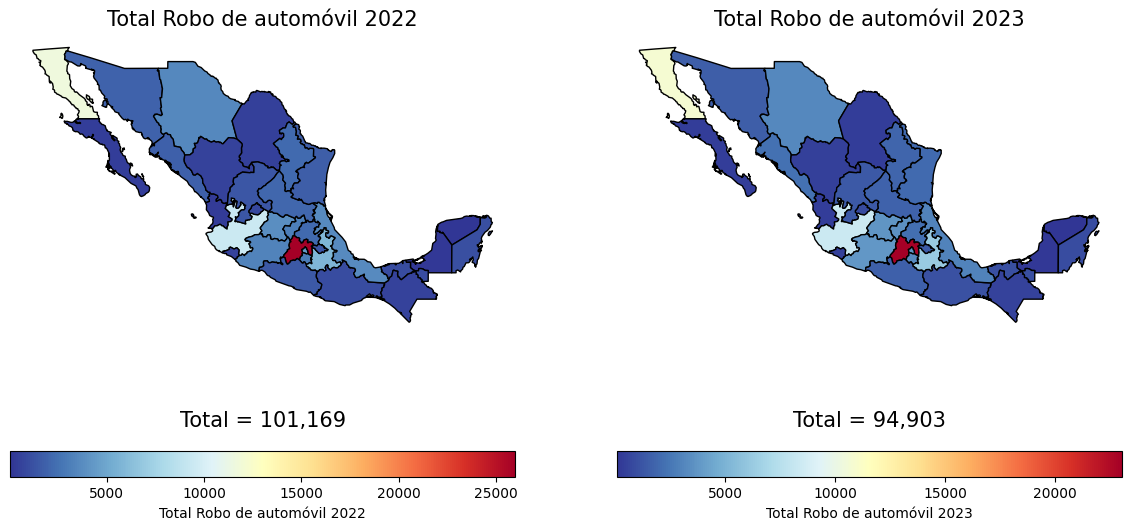

In [ ]:
# Grafico Mapa de Estado a nivel estatal

# Grafico Mapa de Estado a nivel municipal

# Notación,
# HOM - Homicidio
# LES - Lesiones
# SEC - Secuestro
# EXT - Extorsión
# FRA - Fraude
# AME - Amenazas

# VEH - Robo de vehículo
# MOT - Robo de motocicleta
# TRA - Robo a transportista

# RAP - Robo de autopartes

# Selección grupal
label_1 = 'Distribución poblacional'
field_1 = 'POBTOT'

label_2 = 'Total Robo de automóvil 2022'
field_2 = 'TOT_2022_VEH'

label_3 = 'Total Robo de automóvil 2023'
field_3 = 'TOT_2023_VEH'

label_4 = 'Distancia vs Media Octubre 2023 U12'
field_4 = 'VS_AVG_HOM'
field_4_1 = 'AVG_HOM'

local_x =  0.50
local_y = -0.30

plt.figure(figsize=(30,10), facecolor='w')

# ax1 = plt.subplot(141)
# ax1.set_axis_off()
# ax1.set_title(label_1, fontsize=15, loc='center')
# ax1.text(local_x, local_y, 'Total = '+ str(format(round(df012[field_1].sum()),'0,.0f')), fontsize=15, transform = ax1.transAxes, horizontalalignment = 'center')
# df012.plot(field_1,
#           edgecolor='black',
#           legend=True,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

ax2 = plt.subplot(142)
ax2.set_axis_off()
ax2.set_title(label_2, fontsize=15, loc='center')
ax2.text(local_x, local_y, 'Total = '+ str(format(round(df012[field_2].sum()),'0,.0f')), fontsize=15, transform = ax2.transAxes, horizontalalignment = 'center')
df012.plot(field_2,
          edgecolor='black',
          legend=True,
          legend_kwds={'label': label_2,'orientation': 'horizontal'},
          cmap='RdYlBu_r',
          ax=ax2
         )

ax3 = plt.subplot(143)
ax3.set_axis_off()
ax3.set_title(label_3, fontsize=15, loc='center')
ax3.text(local_x, local_y, 'Total = '+ str(format(round(df012[field_3].sum()),'0,.0f')), fontsize=15, transform = ax3.transAxes, horizontalalignment = 'center')
df012.plot(field_3,
          edgecolor='black',
          legend=True,
          legend_kwds={'label': label_3,'orientation': 'horizontal'},
          cmap='RdYlBu_r',
          ax=ax3
         )

# ax4 = plt.subplot(144)
# ax4.set_axis_off()
# ax4.set_title(label_4, fontsize=15, loc='center')
# ax4.text(local_x, local_y, 'Media U12 = '+ str(format(round(df012[field_4_1].mean()),'0,.0f')), fontsize=15, transform = ax4.transAxes, horizontalalignment = 'center')
# df012.plot(field_4,
#           edgecolor='black',
#           legend=True,
#           legend_kwds={'label': label_4,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax4
#          )

plt.show()


In [ ]:
# # Gráfico de barras (1)
# df_edo = df012.where(df012[field_1]>0).groupby(by='NOM_ENT').agg({field_1:'sum'}).sort_values(by=field_1, ascending=False) #Orden descendente
# lista = list(df_edo.index)

# x = np.array(range(0,len(df_edo)))
# y = np.array ( list(df_edo[field_1]) )
# my_cmap = plt.get_cmap('RdYlBu_r')
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(20,5), facecolor='w')
# plt.bar(x[:10], df_edo[field_1][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
# # plt.title(label_1, fontsize=20, loc='right')
# plt.show()

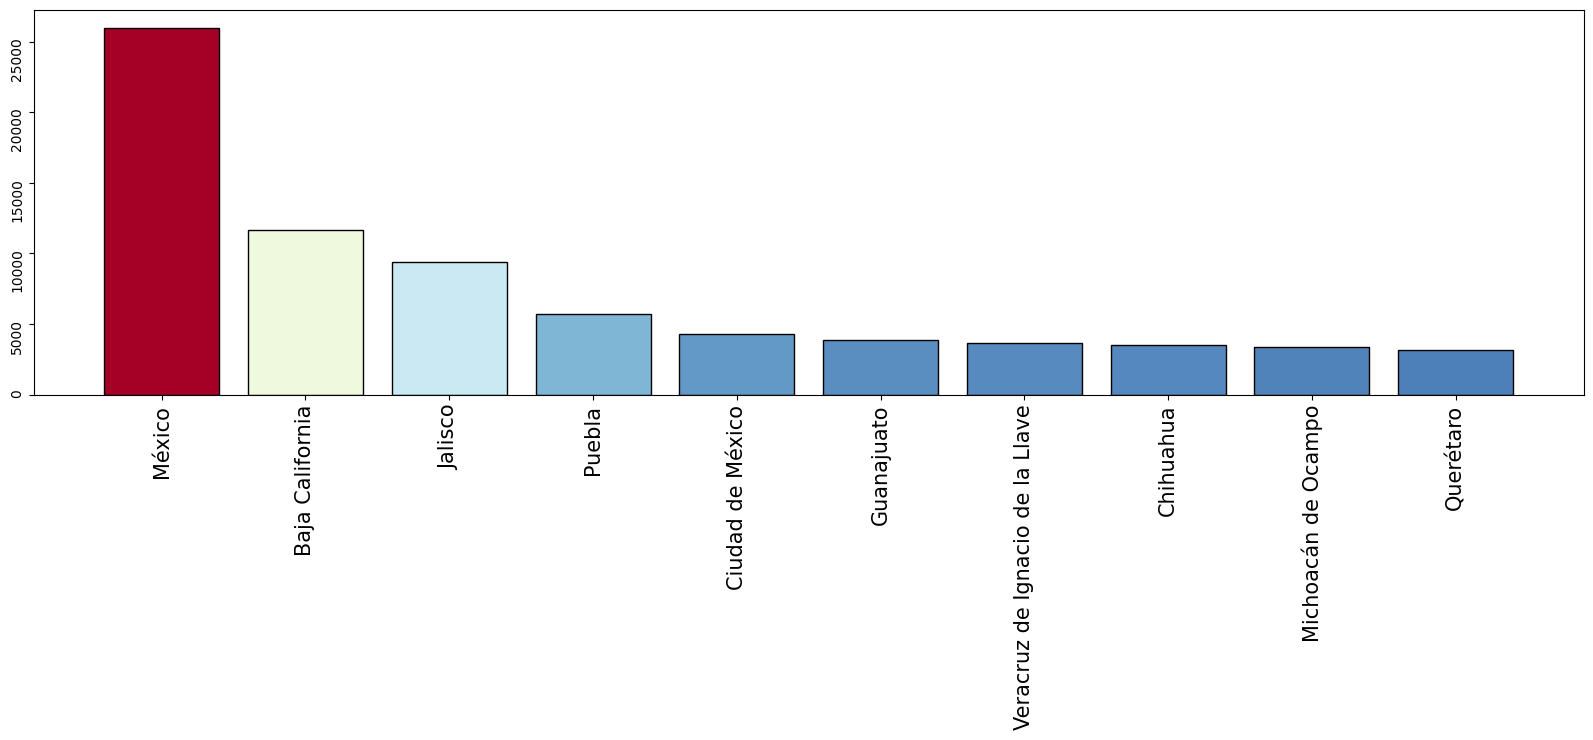

In [ ]:
# Gráfico de barras (2)
df_edo = df012.where(df012[field_2]>0).groupby(by='NOM_ENT').agg({field_2:'sum'}).sort_values(by=field_2, ascending=False) #Orden descendente
lista = list(df_edo.index)

x = np.array(range(0,len(df_edo)))
y = np.array ( list(df_edo[field_2]) )
my_cmap = plt.get_cmap('RdYlBu_r')
rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

plt.figure(figsize=(20,5), facecolor='w')
plt.bar(x[:10], df_edo[field_2][:10], edgecolor='k',color=my_cmap(rescale(y)))
plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
plt.yticks(rotation=90, fontsize=10)
# plt.title(label_2+' , Top 10 Estados', fontsize=10, loc='right')
plt.show()

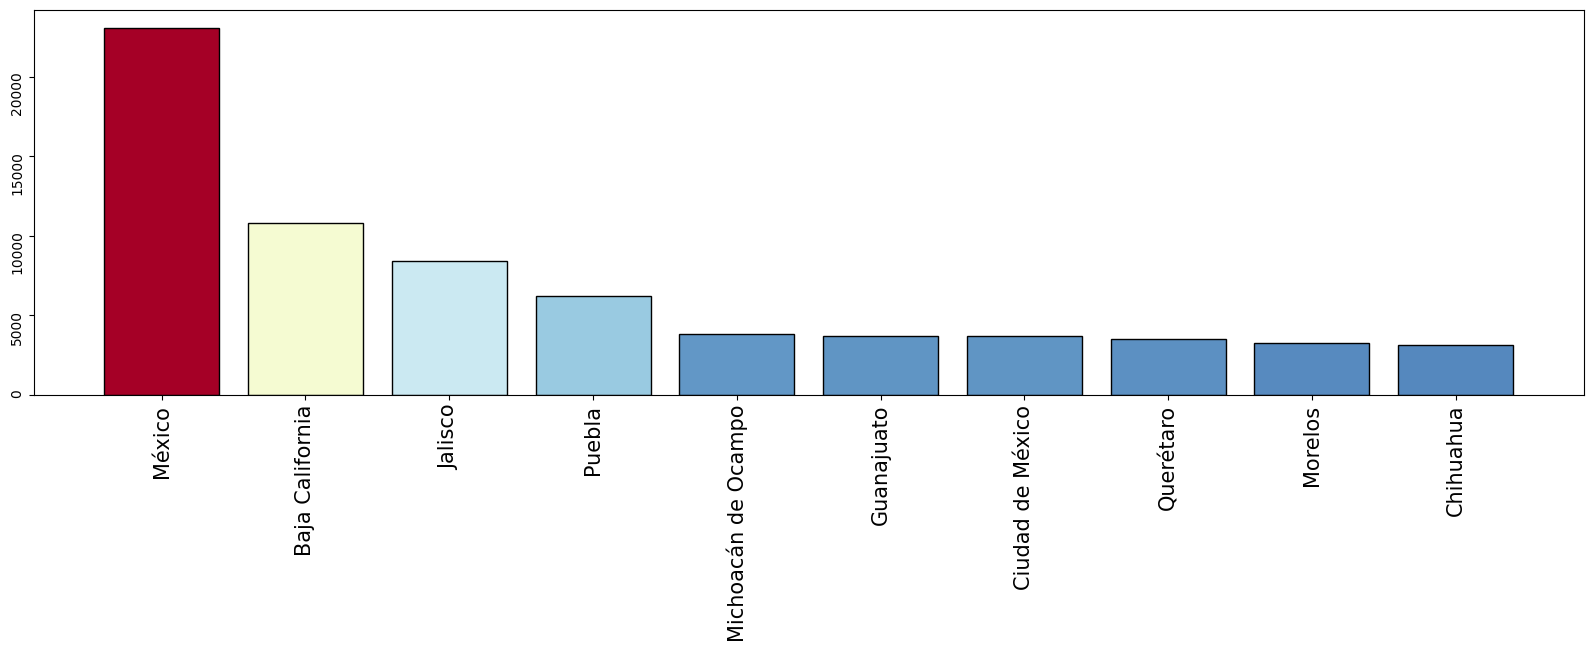

In [ ]:
# Gráfico de barras (3)
df_edo = df012.where(df012[field_3]>0).groupby(by='NOM_ENT').agg({field_3:'sum'}).sort_values(by=field_3, ascending=False) #Orden descendente
lista = list(df_edo.index)

x = np.array(range(0,len(df_edo)))
y = np.array ( list(df_edo[field_3]) )
my_cmap = plt.get_cmap('RdYlBu_r')
rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

plt.figure(figsize=(20,5), facecolor='w')
plt.bar(x[:10], df_edo[field_3][:10], edgecolor='k',color=my_cmap(rescale(y)))
plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
plt.yticks(rotation=90, fontsize=10)
# plt.title(label_3+' , Top 10 Estados', fontsize=10, loc='right')
plt.show()

In [ ]:
# # Gráfico de barras (4)

# # prom = avg_hom_nac
# # prom = avg_les_nac
# # prom = avg_sec_nac
# # prom = avg_ext_nac
# # prom = avg_fra_nac
# # prom = avg_ame_nac
# # prom = avg_veh_nac
# # prom = avg_mot_nac
# # prom = avg_tra_nac

# df_edo = df012.where(df012[field_3]>=-1).groupby(by='NOM_ENT').agg({field_3:'sum'}).sort_values(by=field_3, ascending=False) #Orden descendente
# lista = list(df_edo.index)

# x = np.array(range(0,len(df_edo)))
# y = np.array ( list(df_edo[field_3]) )
# my_cmap = plt.get_cmap("RdYlBu_r")
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(10,5), facecolor='w')
# plt.bar(x[:10], df_edo[field_3][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation=90, fontsize=10)
# plt.yticks(color='k', fontsize=7.5, rotation=90)
# plt.title('Extorsión, Total por entidad TOP 10, Enero-Julio 2023', fontsize=10, loc='right')

# # plt.text(30.3, 7.0, 'Media U12 = '+ str(format(prom,'0,.0f')), fontsize=8, horizontalalignment = 'center')
# plt.text(8.5, 2400.0, 'Promedio Enero-Julio 2023 = '+ str(format(prom,'0,.0f')), fontsize=8, horizontalalignment = 'center')

# plt.show()

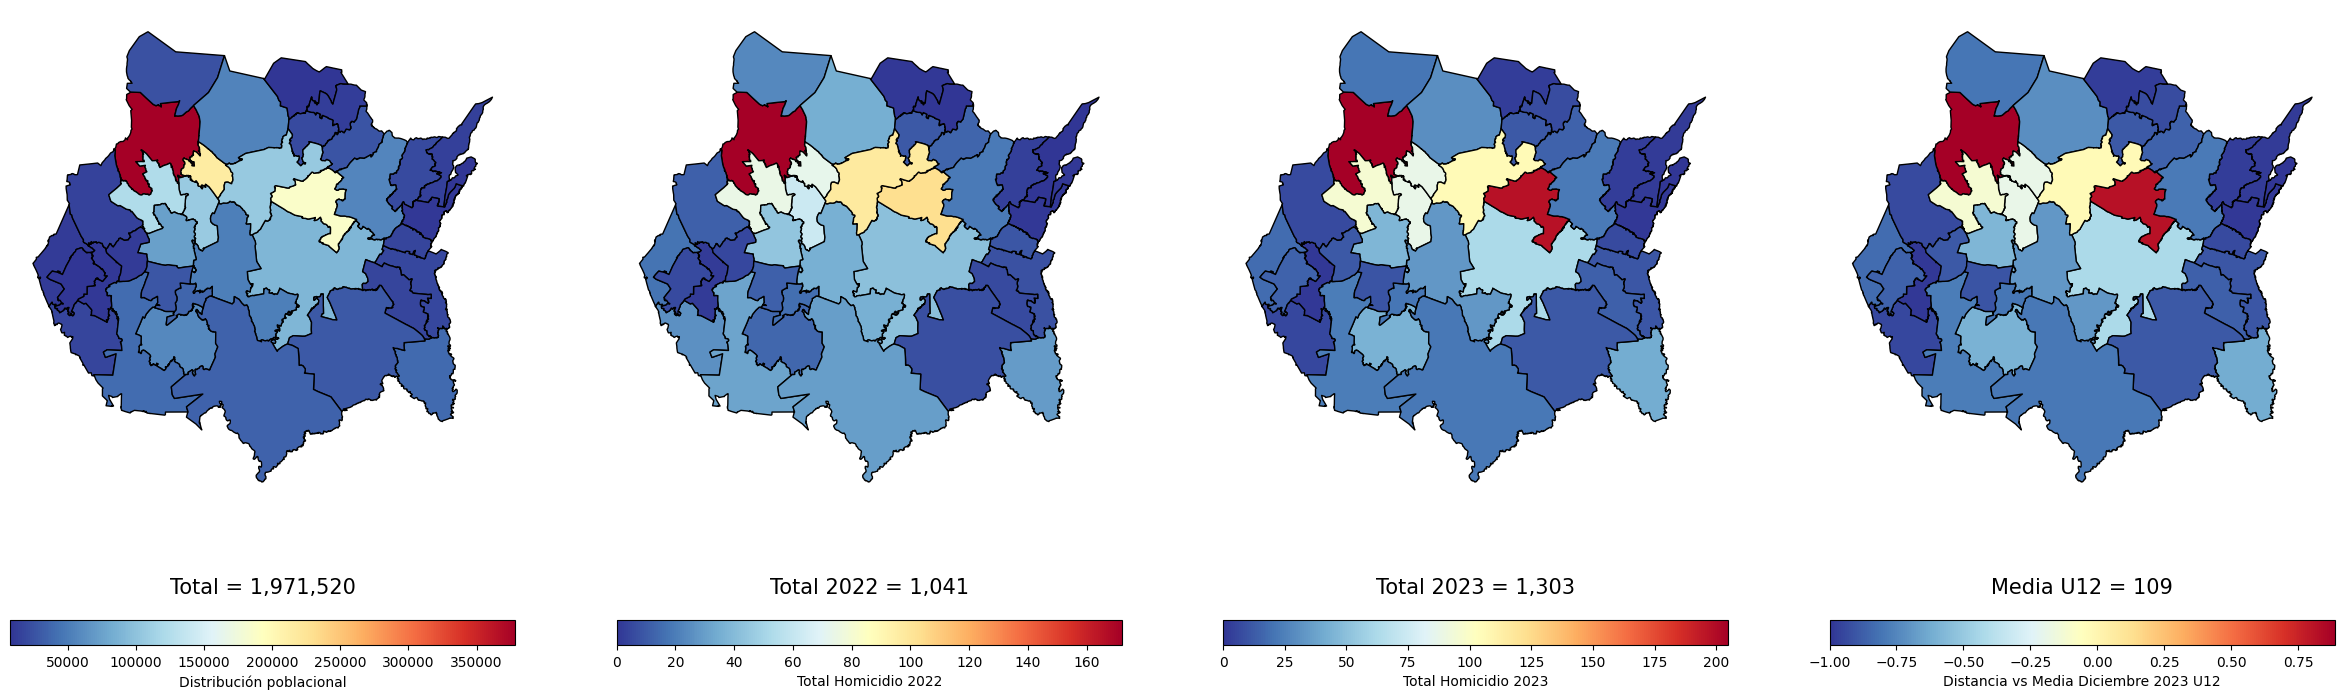

In [ ]:
# # Grafico Mapa de Estado a nivel municipal

# # Notación,
# # HOM - Homicidio
# # LES - Lesiones
# # SEC - Secuestro
# # EXT - Extorsión
# # FRA - Fraude
# # AME - Amenazas

# # VEH - Robo de vehiculo
# # MOT - Robo de motocicleta
# # TRA - Robo a transportista

# # RAP - Robo de autopartes

# # Selección grupal
# values=['Ciudad de México']
# values=['México']
# values=['Jalisco']
# values=['Nuevo León']

values = ['Morelos']


label_1 = 'Distribución poblacional'
field_1 = 'POBTOT'

label_2 = 'Total Homicidio 2022'
field_2 = 'TOT_2022_HOM'

label_3 = 'Total Homicidio 2023'
field_3 = 'TOT_2023_HOM'
# field_3 = 'TOT_DEL_2023'

label_4 = 'Distancia vs Media Diciembre 2023 U12'
field_4 = 'VS_AVG_HOM'
field_4_1 = 'AVG_HOM'

local_x =  0.50
local_y = -0.18

# ### Delitos ###

zoom_edo = df23[df23.NOM_ENT_x.isin(values)]
plt.figure(figsize=(30,10), facecolor='w')
# plt.figure(figsize=(30,10), facecolor='none') # Para hacer figuras sin fondo


ax1 = plt.subplot(141)
ax1.set_axis_off()
ax1.text(local_x, local_y, 'Total = '+ str(format(round(zoom_edo[field_1].sum()),'0,.0f')), fontsize=15, transform = ax1.transAxes, horizontalalignment = 'center')
zoom_edo.plot(field_1,
          edgecolor='black',
          legend=True,
          legend_kwds={'label': label_1,'orientation': 'horizontal'},
          cmap='RdYlBu_r',
          ax=ax1
         )

ax2 = plt.subplot(142)
ax2.set_axis_off()
ax2.text(local_x, local_y, 'Total 2022 = '+ str(format(round(zoom_edo[field_2].sum()),'0,.0f')), fontsize=15, transform = ax2.transAxes, horizontalalignment = 'center')
zoom_edo.plot(field_2,
          edgecolor='black',
          legend=True,
          legend_kwds={'label': label_2 ,'orientation': 'horizontal'},
          cmap='RdYlBu_r',
          ax=ax2
         )

ax3 = plt.subplot(143)
ax3.set_axis_off()
ax3.text(local_x, local_y, 'Total 2023 = '+ str(format(round(zoom_edo[field_3].sum()),'0,.0f')), fontsize=15, transform = ax3.transAxes, horizontalalignment = 'center')
zoom_edo.plot(field_3,
          edgecolor='black',
          legend=True,
          legend_kwds={'label': label_3 ,'orientation': 'horizontal'},
          cmap='RdYlBu_r',
          ax=ax3
         )

ax4 = plt.subplot(144)
ax4.set_axis_off()
ax4.text(local_x, local_y, 'Media U12 = '+ str(format(round(zoom_edo[field_4_1].mean()),'0,.0f')), fontsize=15, transform = ax4.transAxes, horizontalalignment = 'center')
zoom_edo.plot(field_4,
          edgecolor='black',
          legend=True,
          legend_kwds={'label': label_4,'orientation': 'horizontal'},
          cmap='RdYlBu_r',
          ax=ax4,
         )


# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_"+values[0]+"00.png", bbox_inches = 'tight')
plt.show()

In [ ]:
# # # # Gráfico de barras a nivel municipal (1)

# df_zoom = zoom_edo.where(df23[field_1]>0).groupby(by='NOM_MUN_x').agg({field_1:'sum'}).sort_values(by=field_1, ascending=False) #Orden descendente
# lista = list(df_zoom.index)

# x = np.array(range(0,len(df_zoom)))
# y = np.array ( list(df_zoom[field_1]) )
# my_cmap = plt.get_cmap("RdYlBu_r")
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(10,5), facecolor='w')
# plt.bar(x[:10], df_zoom[field_1][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
# plt.yticks(color='k', rotation=90)
# # plt.title('Robo de Vehiculo Enero 23 - U12', fontsize=20, loc='right')

# # plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_"+values[0]+"01.png", bbox_inches = 'tight')
# plt.show()

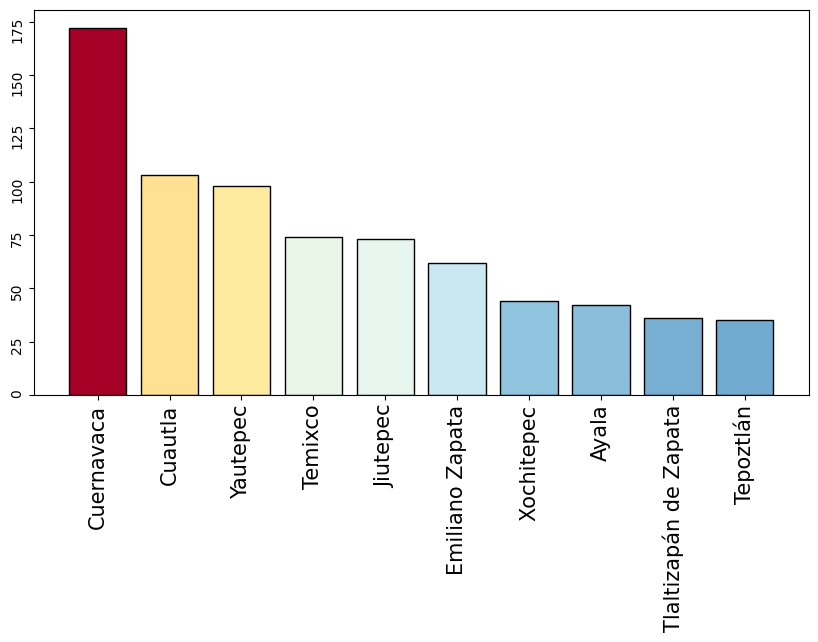

In [ ]:
# Gráfico de barras a nivel municipal (2)

df_zoom = zoom_edo.where(df23[field_2]>0).groupby(by='NOM_MUN_x').agg({field_2:'sum'}).sort_values(by=field_2, ascending=False) #Orden descendente
lista = list(df_zoom.index)

x = np.array(range(0,len(df_zoom)))
y = np.array ( list(df_zoom[field_2]) )
my_cmap = plt.get_cmap("RdYlBu_r")
rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

plt.figure(figsize=(10,5), facecolor='w')
plt.bar(x[:10], df_zoom[field_2][:10], edgecolor='k',color=my_cmap(rescale(y)))
plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
plt.yticks(color='k', rotation=90)
# plt.title('Robo de Vehiculo Enero 23 - U12', fontsize=20, loc='right')

# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_"+values[0]+"02.png", bbox_inches = 'tight')
plt.show()

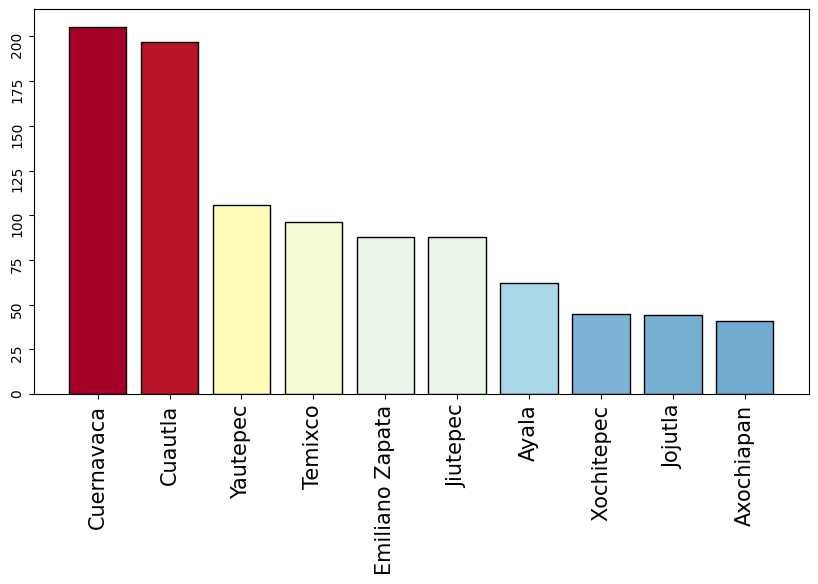

In [ ]:
# Gráfico de barras a nivel municipal (3)

df_zoom = zoom_edo.where(df23[field_3]>0).groupby(by='NOM_MUN_x').agg({field_3:'sum'}).sort_values(by=field_3, ascending=False) #Orden descendente
lista = list(df_zoom.index)

x = np.array(range(0,len(df_zoom)))
y = np.array ( list(df_zoom[field_3]) )
my_cmap = plt.get_cmap("RdYlBu_r")
rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

plt.figure(figsize=(10,5), facecolor='w')
plt.bar(x[:10], df_zoom[field_3][:10], edgecolor='k',color=my_cmap(rescale(y)))
plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
plt.yticks(color='k', rotation=90)
# plt.title('Robo de Vehiculo Enero 23 - U12', fontsize=20, loc='right')

# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_"+values[0]+"03.png", bbox_inches = 'tight')
plt.show()

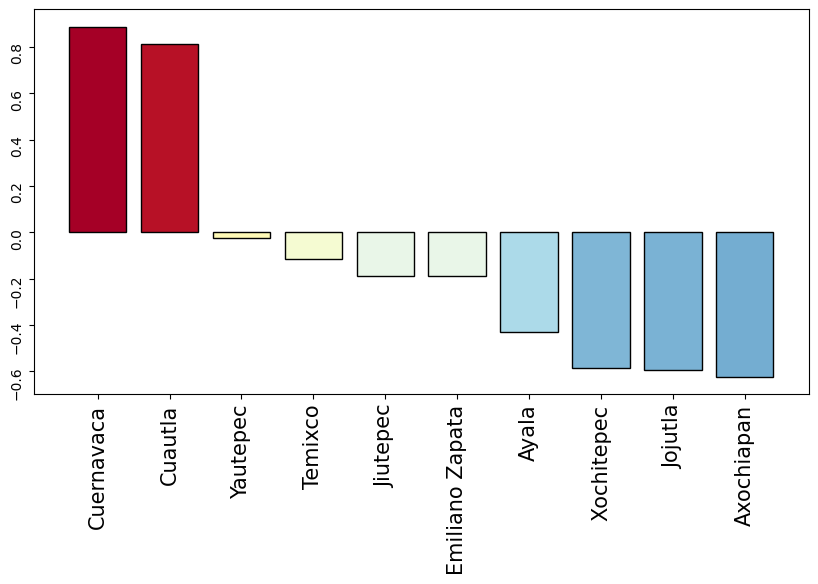

In [ ]:
# # Gráfico de barras a nivel municipal (4)

df_zoom = zoom_edo.where(df23[field_4]>=-1).groupby(by='NOM_MUN_x').agg({field_4:'sum'}).sort_values(by=field_4, ascending=False) #Orden descendente
lista = list(df_zoom.index)

x = np.array(range(0,len(df_zoom)))
y = np.array ( list(df_zoom[field_4]) )
my_cmap = plt.get_cmap("RdYlBu_r")
rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

plt.figure(figsize=(10,5), facecolor='w')
plt.bar(x[:10], df_zoom[field_4][:10], edgecolor='k',color=my_cmap(rescale(y)))
plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
plt.yticks(color='k', rotation=90)
# plt.title('Robo de Vehiculo Enero 23 - U12', fontsize=20, loc='right')

# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_"+values[0]+"04.png", bbox_inches = 'tight')
plt.show()

In [ ]:
# Manipulacion de imagenes
# (1) Corte solo de mapa principal
# (2) Corte solo escalas
# (3) Rotacion de graficas de barras

In [ ]:
# img_00 = Image.open('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'00.png')

# img_01 = Image.open('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'01.png')
# img_02 = Image.open('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'02.png')
# img_03 = Image.open('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'03.png')
# img_04 = Image.open('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'04.png')

In [ ]:
a = img_00.size[0]
b = img_00.size[1]
img_map = img_00.crop((0,0,a,b*0.8))
# img_map = img_00.crop((0,0,a,b*0.70))
img_map

NameError: name 'img_00' is not defined

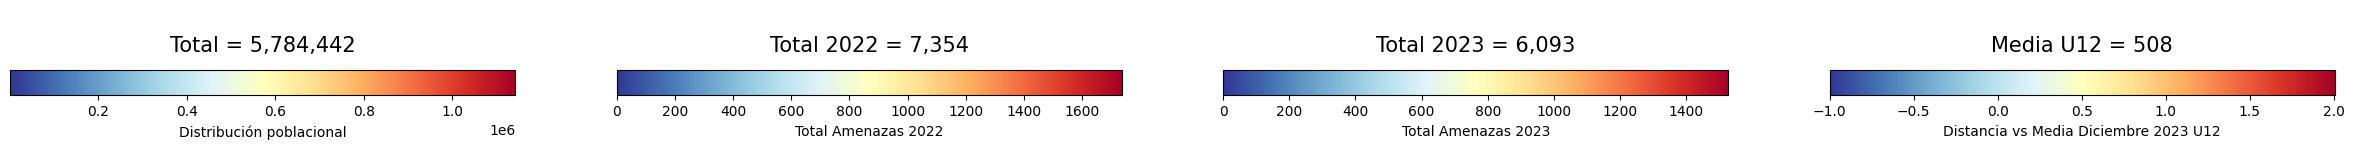

In [ ]:
a = img_00.size[0]
b = img_00.size[1]
img_scale = img_00.crop((0,b*0.8,a,b))
# img_scale = img_00.crop((0,b*0.70,a,b))
img_scale

In [ ]:
# img_01 = img_01.rotate(270, expand=True)
# img_02 = img_02.rotate(270, expand=True)
img_03 = img_03.rotate(270, expand=True)
img_04 = img_04.rotate(270, expand=True)

In [ ]:
# Mapa sin barras de escala
img_map.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'00.png')
img_scale.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'00S.png')


# Graficos de barras asociados a los mapas.
# img_01.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'01.png')
# img_02.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'02.png')
img_03.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'03.png')
img_04.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_'+values[0]+'04.png')

In [ ]:
# #### TEST 2 ####
# #### Generación estados TOP por delito ####

# # HOM - Homicidio
# # LES - Lesiones
# # SEC - Secuestro
# # EXT - Extorsión
# # FRA - Fraude
# # AME - Amenazas

# # VEH - Robo de vehiculo
# # MOT - Robo de motocicleta
# # TRA - Robo a transportista

# # RAP - Robo de autopartes
# # Selección grupal

# value_01=['Chihuahua', 'Coahuila de Zaragoza', 'Durango','Nuevo León','Tamaulipas']
# value_02=['Puebla']
# value_03=['Michoacán de Ocampo']
# value_04=['San Luis Potosí']

# fields = 'TOT_2023_TRA'

# label_1 = 'Total Robo a transportista 2023'
# label_2 = 'Total Robo a transportista 2023'
# label_3 = 'Total Robo a transportista 2023'
# label_4 = 'Total Robo a transportista 2023'

# local_x =  0.50
# local_y = -0.18

# ### Delitos ###

# zoom_edo_01 = df23[df23.NOM_ENT_x.isin(value_01)]
# zoom_edo_02 = df23[df23.NOM_ENT_x.isin(value_02)]
# zoom_edo_03 = df23[df23.NOM_ENT_x.isin(value_03)]
# zoom_edo_04 = df23[df23.NOM_ENT_x.isin(value_04)]

# plt.figure(figsize=(30,10), facecolor='w')
# plt.figure(figsize=(30,10), facecolor='none') # Para hacer figuras sin fondo


# ax1 = plt.subplot(141)
# ax1.set_axis_off()
# ax1.text(local_x, local_y, 'Total = '+ str(format(round(zoom_edo_01[fields].sum()),'0,.0f')), fontsize=15, transform = ax1.transAxes, horizontalalignment = 'center')
# zoom_edo_01.plot(fields,
#           edgecolor='black',
#           legend=True,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax2 = plt.subplot(142)
# ax2.set_axis_off()
# ax2.text(local_x, local_y, 'Total = '+ str(format(round(zoom_edo_02[fields].sum()),'0,.0f')), fontsize=15, transform = ax2.transAxes, horizontalalignment = 'center')
# zoom_edo_02.plot(fields,
#           edgecolor='black',
#           legend=True,
#           legend_kwds={'label': label_2 ,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax2
#          )

# ax3 = plt.subplot(143)
# ax3.set_axis_off()
# ax3.text(local_x, local_y, 'Total = '+ str(format(round(zoom_edo_03[fields].sum()),'0,.0f')), fontsize=15, transform = ax3.transAxes, horizontalalignment = 'center')
# zoom_edo_03.plot(fields,
#           edgecolor='black',
#           legend=True,
#           legend_kwds={'label': label_3 ,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax3
#          )

# ax4 = plt.subplot(144)
# ax4.set_axis_off()
# ax4.text(local_x, local_y, 'Total = '+ str(format(round(zoom_edo_04[fields].sum()),'0,.0f')), fontsize=15, transform = ax4.transAxes, horizontalalignment = 'center')
# zoom_edo_04.plot(fields,
#           edgecolor='black',
#           legend=True,
#           legend_kwds={'label': label_4,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax4,
#          )


# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_"+"00.png", bbox_inches = 'tight')
# plt.show()

In [ ]:
# TEST 2 #
# Gráfico de barras delito , ESTADO TOP 1 (1)

# df_zoom_01 = zoom_edo_01.where(df23[fields]>0).groupby(by='NOM_MUN_x').agg({fields:'sum'}).sort_values(by=fields, ascending=False) #Orden descendente
# lista = list(df_zoom_01.index)

# x = np.array(range(0,len(df_zoom_01)))
# y = np.array ( list(df_zoom_01[fields]) )
# my_cmap = plt.get_cmap("RdYlBu_r")
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(10,5), facecolor='w')
# plt.bar(x[:10], df_zoom_01[fields][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
# plt.yticks(color='k', rotation=90)
# plt.title('Robo de Vehiculo Enero 23 - U12', fontsize=20, loc='right')

# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_"+value_01[0]+"01.png", bbox_inches = 'tight')
# plt.show()

In [ ]:
# TEST 2 #
# Gráfico de barras delito , ESTADO TOP 2 (2)

# df_zoom_02 = zoom_edo_02.where(df23[fields]>0).groupby(by='NOM_MUN_x').agg({fields:'sum'}).sort_values(by=fields, ascending=False) #Orden descendente
# lista = list(df_zoom_02.index)

# x = np.array(range(0,len(df_zoom_02)))
# y = np.array ( list(df_zoom_02[fields]) )
# my_cmap = plt.get_cmap("RdYlBu_r")
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(10,5), facecolor='w')
# plt.bar(x[:10], df_zoom_02[fields][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
# plt.yticks(color='k', rotation=90)
# plt.title('Robo de Vehiculo Enero 23 - U12', fontsize=20, loc='right')

# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_"+value_02[0]+"02.png", bbox_inches = 'tight')
# plt.show()

In [ ]:
# TEST 2 #
# Gráfico de barras delito , ESTADO TOP 3 (3)

# df_zoom_03 = zoom_edo_03.where(df23[fields]>0).groupby(by='NOM_MUN_x').agg({fields:'sum'}).sort_values(by=fields, ascending=False) #Orden descendente
# lista = list(df_zoom_03.index)

# x = np.array(range(0,len(df_zoom_03)))
# y = np.array ( list(df_zoom_03[fields]) )
# my_cmap = plt.get_cmap("RdYlBu_r")
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(10,5), facecolor='w')
# plt.bar(x[:10], df_zoom_03[fields][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
# plt.yticks(color='k', rotation=90)
# plt.title('Robo de Vehiculo Enero 23 - U12', fontsize=20, loc='right')

# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_"+value_03[0]+"03.png", bbox_inches = 'tight')
# plt.show()

In [ ]:
# TEST 2 #
# Gráfico de barras delito , ESTADO TOP 4 (4)

# df_zoom_04 = zoom_edo_04.where(df23[fields]>0).groupby(by='NOM_MUN_x').agg({fields:'sum'}).sort_values(by=fields, ascending=False) #Orden descendente
# lista = list(df_zoom_04.index)

# x = np.array(range(0,len(df_zoom_04)))
# y = np.array ( list(df_zoom_04[fields]) )
# my_cmap = plt.get_cmap("RdYlBu_r")
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(10,5), facecolor='w')
# plt.bar(x[:10], df_zoom_04[fields][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
# plt.yticks(color='k', rotation=90)

# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_"+value_04[0]+"04.png", bbox_inches = 'tight')
# plt.show()

In [ ]:
# Manipulacion de imagenes
# (1) Corte solo de mapa principal
# (2) Corte solo escalas
# (3) Rotacion de graficas de barras

In [ ]:
# img_00 = Image.open('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+'00.png')

# img_01 = Image.open('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+value_01[0]+'01.png')
# img_02 = Image.open('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+value_02[0]+'02.png')
# img_03 = Image.open('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+value_03[0]+'03.png')
# img_04 = Image.open('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+value_04[0]+'04.png')

In [ ]:
# a = img_00.size[0]
# b = img_00.size[1]
# img_map = img_00.crop((0,0,a,b*0.8))
# img_map

In [ ]:
# a = img_00.size[0]
# b = img_00.size[1]
# img_scale = img_00.crop((0,b*0.8,a,b))
# img_scale

In [ ]:
# img_01 = img_01.rotate(270, expand=True)
# img_02 = img_02.rotate(270, expand=True)
# img_03 = img_03.rotate(270, expand=True)
# img_04 = img_04.rotate(270, expand=True)

In [ ]:
# # Mapa sin barras de escala
# img_map.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+'00.png')
# img_scale.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+'00S.png')


# Graficos de barras asociados a los mapas.
# img_01.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+value_01[0]+'01.png')
# img_02.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+value_02[0]+'02.png')
# img_03.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+value_03[0]+'03.png')
# img_04.save('/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_'+value_04[0]+'04.png')

In [ ]:
# #### TEST 2 ####
# #### Generación estados TOP por delito ####

# # HOM - Homicidio
# # LES - Lesiones
# # SEC - Secuestro
# # EXT - Extorsión
# # FRA - Fraude
# # AME - Amenazas

# # VEH - Robo de vehiculo
# # MOT - Robo de motocicleta
# # TRA - Robo a transportista

# # RAP - Robo de autopartes
# # Selección grupal

# value_01=['Puebla']
# value_02=['Michoacán de Ocampo']
# value_03=['Querétaro']
# value_04=['Morelos']

# fields = 'TOT_2023_VEH'
# # fields = 'AME_EXT_2023'

# label_1 = 'Total 2023'
# label_2 = 'Total 2023'
# label_3 = 'Total 2023'
# label_4 = 'Total 2023'

# local_x =  0.50
# local_y = -0.18

# ### Delitos ###

# zoom_edo_01 = df23[df23.NOM_ENT_x.isin(value_01)]
# zoom_edo_02 = df23[df23.NOM_ENT_x.isin(value_02)]
# zoom_edo_03 = df23[df23.NOM_ENT_x.isin(value_03)]
# zoom_edo_04 = df23[df23.NOM_ENT_x.isin(value_04)]

# plt.figure(figsize=(30,10), facecolor='w')
# # plt.figure(figsize=(10,10), facecolor='none') # Para hacer figuras sin fondo


# ax1 = plt.subplot(141)
# ax1.set_axis_off()
# ax1.text(local_x, local_y, 'Total 2023 = '+ str(format(round(zoom_edo_01[fields].sum()),'0,.0f')), fontsize=15, transform = ax1.transAxes, horizontalalignment = 'center')
# zoom_edo_01.plot(fields,
#           edgecolor='black',
#           legend=True,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax2 = plt.subplot(142)
# ax2.set_axis_off()
# ax2.text(local_x, local_y, 'Total 2023 = '+ str(format(round(zoom_edo_02[fields].sum()),'0,.0f')), fontsize=15, transform = ax2.transAxes, horizontalalignment = 'center')
# zoom_edo_02.plot(fields,
#           edgecolor='black',
#           legend=True,
#           legend_kwds={'label': label_2 ,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax2
#          )

# ax3 = plt.subplot(143)
# ax3.set_axis_off()
# # ax3.text(local_x, local_y, 'Total 2023 = '+ str(format(round(zoom_edo_03[fields].sum()),'0,.0f')), fontsize=15, transform = ax3.transAxes, horizontalalignment = 'center')
# ax3.text(local_x, local_y, 'Total 2023 = 3,495', fontsize=15, transform = ax3.transAxes, horizontalalignment = 'center')
# zoom_edo_03.plot(fields,
#           edgecolor='black',
#           legend=True,
#           legend_kwds={'label': label_3 ,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax3
#          )

# ax4 = plt.subplot(144)
# ax4.set_axis_off()
# ax4.text(local_x, local_y, 'Total 2023 = '+ str(format(round(zoom_edo_04[fields].sum()),'0,.0f')), fontsize=15, transform = ax4.transAxes, horizontalalignment = 'center')
# # ax4.text(local_x, local_y, 'Total 2023 = 2,477', fontsize=15, transform = ax4.transAxes, horizontalalignment = 'center')
# zoom_edo_04.plot(fields,
#           edgecolor='black',
#           legend=True,
#           legend_kwds={'label': label_4,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax4,
#          )


# # plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_"+"00.png", bbox_inches = 'tight')
# plt.show()

In [ ]:
# # # Gráfico de barras delito , ESTADO TOP 1 (1)

# df_zoom_01 = zoom_edo_04.where(df23[fields]>0).groupby(by='NOM_MUN_x').agg({fields:'sum'}).sort_values(by=fields, ascending=False) #Orden descendente
# lista = list(df_zoom_01.index)

# x = np.array(range(0,len(df_zoom_01)))
# y = np.array ( list(df_zoom_01[fields]) )
# my_cmap = plt.get_cmap("RdYlBu_r")
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(10,5), facecolor='w')
# plt.bar(x[:10], df_zoom_01[fields][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
# plt.yticks(color='k', rotation=90)

# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito_"+value_01[0]+"01.png", bbox_inches = 'tight')
# plt.show()

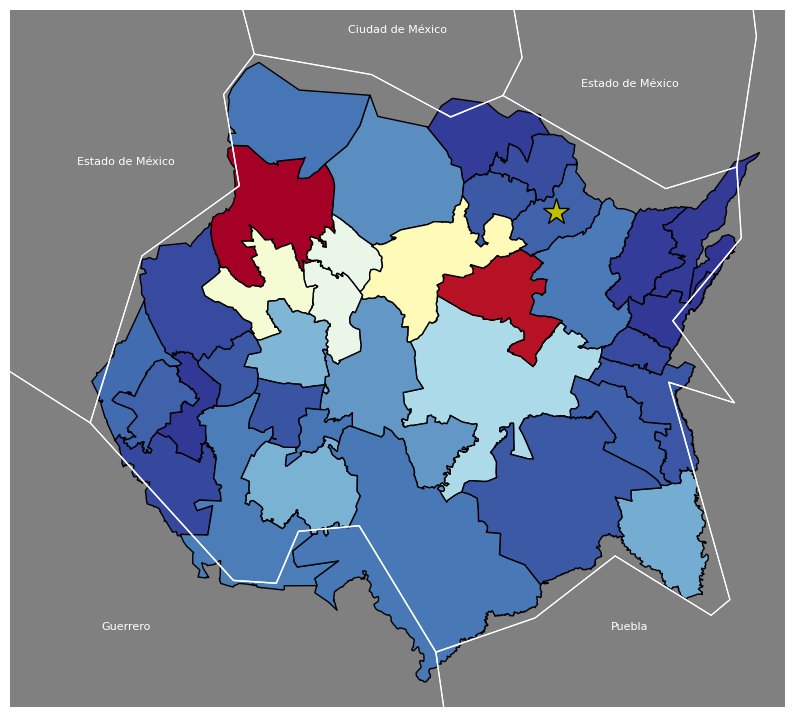

In [ ]:
#Grafico Mapa Nivel Nacional Zonas de Alto Riesgo TEST 1#
## Delitos de Amenaza y Extorsión##

### Delitos ###
# field_1='AME_EXT_2023'
# field_1='DEL_AGE_2023'
# field_1='TOT_DEL_2023'
# field_1='TOT_2023_TRA'
field_1='TOT_2023_HOM'

label_1=" Total Homicidios 2023"
# label_1='Total Robo a trnsportista 2023'

### Desarrollando regiones ###
### # Metropolitano
# zoom_edo_CMX = df23[df23.NOM_ENT_x.isin(['Ciudad de México'])]
# zoom_edo_MEX = df23[df23.NOM_ENT_x.isin(['México'])]
# zoom_edo_HID = df23[df23.NOM_ENT_x.isin(['Hidalgo'])]
zoom_edo_MOR = df23[df23.NOM_ENT_x.isin(['Morelos'])]

### # Noroeste
# zoom_edo_BCN = df23[df23.NOM_ENT_x.isin(['Baja California'])]
# zoom_edo_BCS = df23[df23.NOM_ENT_x.isin(['Baja California Sur'])]
# zoom_edo_SIN = df23[df23.NOM_ENT_x.isin(['Sinaloa'])]
# zoom_edo_SON = df23[df23.NOM_ENT_x.isin(['Sonora'])]

### # Noreste
# zoom_edo_CHH = df23[df23.NOM_ENT_x.isin(['Chihuahua'])]
# zoom_edo_COA = df23[df23.NOM_ENT_x.isin(['Coahuila de Zaragoza'])]
# zoom_edo_DUR = df23[df23.NOM_ENT_x.isin(['Durango'])]
# zoom_edo_NLE = df23[df23.NOM_ENT_x.isin(['Nuevo León'])]
# zoom_edo_TAM = df23[df23.NOM_ENT_x.isin(['Tamaulipas'])]

### # Occidente
# zoom_edo_AGU = df23[df23.NOM_ENT_x.isin(['Aguascalientes'])]
# zoom_edo_COL = df23[df23.NOM_ENT_x.isin(['Colima'])]
# zoom_edo_GUA = df23[df23.NOM_ENT_x.isin(['Guanajuato'])]
# zoom_edo_JAL = df23[df23.NOM_ENT_x.isin(['Jalisco'])]
# zoom_edo_MIC = df23[df23.NOM_ENT_x.isin(['Michoacán de Ocampo'])]
# zoom_edo_NAY = df23[df23.NOM_ENT_x.isin(['Nayarit'])]
# zoom_edo_QUE = df23[df23.NOM_ENT_x.isin(['Querétaro'])]
# zoom_edo_SLP = df23[df23.NOM_ENT_x.isin(['San Luis Potosí'])]
# zoom_edo_ZAC = df23[df23.NOM_ENT_x.isin(['Zacatecas'])]

### # Sureste I
# zoom_edo_GUE = df23[df23.NOM_ENT_x.isin(['Guerrero'])]
# zoom_edo_TLA = df23[df23.NOM_ENT_x.isin(['Tlaxcala'])]
# zoom_edo_VER = df23[df23.NOM_ENT_x.isin(['Veracruz de Ignacio de la Llave'])]
# zoom_edo_OAX = df23[df23.NOM_ENT_x.isin(['Oaxaca'])]
# zoom_edo_PUE = df23[df23.NOM_ENT_x.isin(['Puebla'])]

### # Sureste II
# zoom_edo_CAM = df23[df23.NOM_ENT_x.isin(['Campeche'])]
# zoom_edo_CHP = df23[df23.NOM_ENT_x.isin(['Chiapas'])]
# zoom_edo_TAB = df23[df23.NOM_ENT_x.isin(['Tabasco'])]
# zoom_edo_ROO = df23[df23.NOM_ENT_x.isin(['Quintana Roo'])]
# zoom_edo_YUC = df23[df23.NOM_ENT_x.isin(['Yucatán'])]

plt.figure(figsize=(10,10), facecolor='w')
# plt.figure(figsize=(30,10), facecolor='none') # Para hacer figuras sin fondo

ax1 = plt.subplot(111)
#### Para hacer fondo
mexico_edo.plot(color = 'gray', edgecolor='k', ax=ax1)

#Metropolitano#
# ax1 = plt.subplot(111)
# zoom_edo_CMX.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_HID.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_MEX.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

ax1 = plt.subplot(111)
zoom_edo_MOR.plot(field_1,
          edgecolor='black',
          legend=False,
          legend_kwds={'label': label_1,'orientation': 'horizontal'},
          cmap='RdYlBu_r',
          ax=ax1
         )

#Noroeste#
# ax1 = plt.subplot(111)
# zoom_edo_BCN.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_BCS.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_SON.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_SIN.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

#Noreste#

# ax1 = plt.subplot(111)
# zoom_edo_CHH.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_COA.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_DUR.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_NLE.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_TAM.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# #Occidente#

# ax1 = plt.subplot(111)
# zoom_edo_AGU.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_COL.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_GUA.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )


# ax1 = plt.subplot(111)
# zoom_edo_JAL.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_MIC.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )


# ax1 = plt.subplot(111)
# zoom_edo_NAY.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_QUE.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_SLP.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )


# ax1 = plt.subplot(111)
# zoom_edo_ZAC.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# #Sureste I#
# ax1 = plt.subplot(111)
# zoom_edo_GUE.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_OAX.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_PUE.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_TLA.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_VER.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# #Sureste II#
# ax1 = plt.subplot(111)
# zoom_edo_CAM.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )


# ax1 = plt.subplot(111)
# zoom_edo_CHP.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_ROO.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_TAB.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_YUC.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

#Para determinar limites estatales
ax1 = plt.subplot(111)
mexico_edo.plot(color = 'none', edgecolor='w',ax=ax1)


# Limites de vista para cada mapa

# Noroeste
# ax1.set_xlim(-117.5,-105.0)
# ax1.set_ylim(22.0,33.0)

#Noreste
# ax1.set_xlim(-110.5,-97.0)
# ax1.set_ylim(22.0,32.0)

# Occidente
# ax1.set_xlim(-106.0,-98.0)
# ax1.set_ylim(17.5,25.5)

# Jalisco
# ax1.set_xlim(-106.0,-101)
# ax1.set_ylim(18.0,23.0)

#Metropolitano
# ax1.set_xlim(-101.0,-97.5)
# ax1.set_ylim(18.0,21.5)

#Morelos
ax1.set_xlim(-99.6,-98.6)
ax1.set_ylim(18.3,19.2)


## Sureste I
# ax1.set_xlim(-102.5,-93.5)
# ax1.set_ylim(14.5,23.0)

# Puebla-Tlaxcala
# ax1.set_xlim(-99.25,-96.5)
# ax1.set_ylim(17.5,21.0)


# Sureste II
# ax1.set_xlim(-94.5,-86.0)
# ax1.set_ylim(14,22.0)

plt.text(-99.1, 19.17, 'Ciudad de México', color='w', fontsize=8, horizontalalignment = 'center')
plt.text(-99.45, 19.00, 'Estado de México', color='w', fontsize=8, horizontalalignment = 'center')
plt.text(-98.80, 19.10, 'Estado de México', color='w', fontsize=8, horizontalalignment = 'center')
plt.text(-99.45, 18.40, 'Guerrero', color='w', fontsize=8, horizontalalignment = 'center')
plt.text(-98.80,18.40, 'Puebla', color='w', fontsize=8, horizontalalignment = 'center')

plt.plot(-98.89611006731498, 18.938200319027775,'*', mfc='y', mec='k', mew='1', markersize=20)

ax1.set_axis_off()
plt.show()

In [ ]:
# # Gráfico de barras delito , ESTADO TOP 1 (1)
# field_1='TOT_2023_TRA'
# field_1='TOT_DEL_2023'

# zoom_edo = zoom_edo_PUE

# df_zoom= zoom_edo.where(df23[field_1]>0).groupby(by='NOM_MUN_x').agg({field_1:'sum'}).sort_values(by=field_1, ascending=False) #Orden descendente
# lista = list(df_zoom.index)

# x = np.array(range(0,len(df_zoom)))
# y = np.array ( list(df_zoom[field_1]) )
# my_cmap = plt.get_cmap("RdYlBu_r")
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(10,5), facecolor='w')
# plt.bar(x[:10], df_zoom[field_1][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
# plt.yticks(color='k', rotation=90)


# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito"+"01.png", bbox_inches = 'tight')
# plt.show()

In [ ]:
# gdf_fed = gpd.read_file('/content/drive/MyDrive/1-UIE-2023/JMDJV/Meteorologico/gdf_fed.geojson')
# gdf_est = gpd.read_file('/content/drive/MyDrive/1-UIE-2023/JMDJV/Meteorologico/gdf_est.geojson')
# gdf_est.head(5)

In [ ]:
# #Grafico Mapa Nivel Nacional Zonas de Alto Riesgo TEST 1#
# ## Delitos de Amenaza y Extorsión ##
# ## VISTAS DE REGIONES, ESCALAS DE COLOR DIFERENCIADAS POR ESTADOS ##

# ### Delitos ###
# # field_1='AME_EXT_2023'
# # field_1='DEL_AGE_2023'
# field_1='TOT_2023_TRA'
# # field_1='TOT_2023_TRA'

# label_1="Delitos Totales Enero-Noviembre 2023"
# # label_1='Total Robo a trnsportista 2023'

# ### Desarrollando regiones ###
# ### # Metropolitano
# # zoom_edo_CMX = df23[df23.NOM_ENT_x.isin(['Ciudad de México'])]
# zoom_edo_MEX = df23[df23.NOM_ENT_x.isin(['México'])]
# zoom_edo_HID = df23[df23.NOM_ENT_x.isin(['Hidalgo'])]
# # zoom_edo_MOR = df23[df23.NOM_ENT_x.isin(['Morelos'])]

# ### # Noroeste
# # zoom_edo_BCN = df23[df23.NOM_ENT_x.isin(['Baja California'])]
# # zoom_edo_BCS = df23[df23.NOM_ENT_x.isin(['Baja California Sur'])]
# # zoom_edo_SIN = df23[df23.NOM_ENT_x.isin(['Sinaloa'])]
# # zoom_edo_SON = df23[df23.NOM_ENT_x.isin(['Sonora'])]

# ### # Noreste
# # zoom_edo_CHH = df23[df23.NOM_ENT_x.isin(['Chihuahua'])]
# # zoom_edo_COA = df23[df23.NOM_ENT_x.isin(['Coahuila de Zaragoza'])]
# # zoom_edo_DUR = df23[df23.NOM_ENT_x.isin(['Durango'])]
# # zoom_edo_NLE = df23[df23.NOM_ENT_x.isin(['Nuevo León'])]
# # zoom_edo_TAM = df23[df23.NOM_ENT_x.isin(['Tamaulipas'])]

# ### # Occidente
# # zoom_edo_AGU = df23[df23.NOM_ENT_x.isin(['Aguascalientes'])]
# # zoom_edo_COL = df23[df23.NOM_ENT_x.isin(['Colima'])]
# # zoom_edo_GUA = df23[df23.NOM_ENT_x.isin(['Guanajuato'])]
# # zoom_edo_JAL = df23[df23.NOM_ENT_x.isin(['Jalisco'])]
# # zoom_edo_MIC = df23[df23.NOM_ENT_x.isin(['Michoacán de Ocampo'])]
# # zoom_edo_NAY = df23[df23.NOM_ENT_x.isin(['Nayarit'])]
# # zoom_edo_QUE = df23[df23.NOM_ENT_x.isin(['Querétaro'])]
# # zoom_edo_SLP = df23[df23.NOM_ENT_x.isin(['San Luis Potosí'])]
# # zoom_edo_ZAC = df23[df23.NOM_ENT_x.isin(['Zacatecas'])]

# ### # Sureste I
# # zoom_edo_GUE = df23[df23.NOM_ENT_x.isin(['Guerrero'])]
# zoom_edo_TLA = df23[df23.NOM_ENT_x.isin(['Tlaxcala'])]
# # zoom_edo_VER = df23[df23.NOM_ENT_x.isin(['Veracruz de Ignacio de la Llave'])]
# # zoom_edo_OAX = df23[df23.NOM_ENT_x.isin(['Oaxaca'])]
# zoom_edo_PUE = df23[df23.NOM_ENT_x.isin(['Puebla'])]

# ### # Sureste II
# # zoom_edo_CAM = df23[df23.NOM_ENT_x.isin(['Campeche'])]
# # zoom_edo_CHP = df23[df23.NOM_ENT_x.isin(['Chiapas'])]
# # zoom_edo_TAB = df23[df23.NOM_ENT_x.isin(['Tabasco'])]
# # zoom_edo_ROO = df23[df23.NOM_ENT_x.isin(['Quintana Roo'])]
# # zoom_edo_YUC = df23[df23.NOM_ENT_x.isin(['Yucatán'])]

# # Bases municipales
# zoom_edo_HID_MUN = zoom_edo_HID[zoom_edo_HID.NOM_MUN_x.isin(['Tizayuca', 'Tepeapulco'])]
# zoom_edo_PUE_MUN = zoom_edo_PUE[zoom_edo_PUE.NOM_MUN_x.isin(['San Martín Texmelucan'])]
# zoom_edo_TLA_MUN = zoom_edo_TLA[zoom_edo_TLA.NOM_MUN_x.isin(['Calpulalpan'])]


# plt.figure(figsize=(10,10), facecolor='w')
# # plt.figure(figsize=(30,10), facecolor='none') # Para hacer figuras sin fondo

# # ax1 = plt.subplot(111)
# # mexico_mun.plot(color = 'lightgray', edgecolor='k', ax=ax1)
# ##### Para hacer fondo
# # mexico_edo.plot(color = 'gray', edgecolor='k', ax=ax1)

# # Tramo carretero Federal
# # zoom_edo_02 = gdf_fed
# zoom_edo_02 = gdf_fed[gdf_fed.CODIGO.isin(['134'])]

# zoom_edo_03 = gdf_fed[gdf_fed.CODIGO.isin(['57'])]

# zoom_edo_04 = gdf_fed[gdf_fed.CODIGO.isin(['40'])]

# zoom_edo_05 = gdf_est[gdf_est.NOMBRE.isin(['Circuito Exterior Mexiquense Bicentenario'])]

# ax1 = plt.subplot(111)
# mexico_edo.plot(color = 'gray', edgecolor='k', ax=ax1)

# #Metropolitano#
# # ax1 = plt.subplot(111)
# # zoom_edo_CMX.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_HID.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# ax1 = plt.subplot(111)
# zoom_edo_MEX.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           ax=ax1
#          )

# # ax1 = plt.subplot(111)
# # zoom_edo_MOR.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# #Noroeste#
# # ax1 = plt.subplot(111)
# # zoom_edo_BCN.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_BCS.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_SON.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_SIN.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# #Noreste#

# # ax1 = plt.subplot(111)
# # zoom_edo_CHH.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_COA.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_DUR.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_NLE.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_TAM.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # #Occidente#

# # ax1 = plt.subplot(111)
# # zoom_edo_AGU.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_COL.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_GUA.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )


# # ax1 = plt.subplot(111)
# # zoom_edo_JAL.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_MIC.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )


# # ax1 = plt.subplot(111)
# # zoom_edo_NAY.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_QUE.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_SLP.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )


# # ax1 = plt.subplot(111)
# # zoom_edo_ZAC.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # #Sureste I#
# # ax1 = plt.subplot(111)
# # zoom_edo_GUE.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_OAX.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_PUE.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_TLA.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_VER.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # #Sureste II#
# # ax1 = plt.subplot(111)
# # zoom_edo_CAM.plot(field_1,
# #            edgecolor='black',
# #            legend=False,
# #            legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #            cmap='RdYlBu_r',
# #            ax=ax1
# #           )


# # ax1 = plt.subplot(111)
# # zoom_edo_CHP.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_ROO.plot(field_1,
# #            edgecolor='black',
# #            legend=False,
# #            legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #            cmap='RdYlBu_r',
# #            ax=ax1
# #           )


# # ax1 = plt.subplot(111)
# # zoom_edo_TAB.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# # ax1 = plt.subplot(111)
# # zoom_edo_YUC.plot(field_1,
# #           edgecolor='black',
# #           legend=False,
# #           legend_kwds={'label': label_1,'orientation': 'horizontal'},
# #           cmap='RdYlBu_r',
# #           ax=ax1
# #          )

# ax1 = plt.subplot(111)
# zoom_edo_HID_MUN.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           color='Firebrick',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_PUE_MUN.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           color='Firebrick',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_TLA_MUN.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           color='Firebrick',
#           ax=ax1
#          )

# # Naucalpan - Toluca
# zoom_edo_02.plot(color='ivory', linewidth=2, linestyle='-.', marker='x',ax=ax1)

# # México-Querétaro
# zoom_edo_03.plot(color='magenta', linewidth=2, linestyle='-.', marker='x',ax=ax1)
# zoom_edo_04.plot(color='yellow', linewidth=2, linestyle='-.', marker='x',ax=ax1)

# zoom_edo_05.plot(color='lawngreen', linewidth=2, linestyle='-.', marker='x',ax=ax1)

# # mexico_edo.plot(color = 'none', edgecolor='w',ax=ax1)
# # Para determinar limites estatales
# # ax1 = plt.subplot(111)
# # mexico_edo.plot(color = 'none', edgecolor='w',ax=ax1)


# # Limites de vista para cada mapa

# # Noroeste
# # ax1.set_xlim(-117.5,-105.0)
# # ax1.set_ylim(22.0,33.0)

# #Noreste
# # ax1.set_xlim(-110.5,-97.0)
# # ax1.set_ylim(22.0,32.0)

# # Occidente
# # ax1.set_xlim(-106.0,-98.0)
# # ax1.set_ylim(17.5,25.5)

# # Jalisco
# # ax1.set_xlim(-106.0,-101)
# # ax1.set_ylim(18.0,23.0)

# ##Metropolitano
# ax1.set_xlim(-101.0,-97.5)
# ax1.set_ylim(18.0,21.5)

# ## Sureste I
# # ax1.set_xlim(-102.5,-93.5)
# # ax1.set_ylim(14.5,23.0)

# # Puebla-Tlaxcala
# # ax1.set_xlim(-99.25,-96.5)
# # ax1.set_ylim(17.5,21.0)

# # Sureste II
# # ax1.set_xlim(-94.5,-86.0)
# # ax1.set_ylim(14,22.0)

# # Yucatán
# # ax1.set_xlim(-90.5,-87.4)
# # ax1.set_ylim(19.4,21.75)


# # MEX - CARRETERAS PELIGROSAS
# ax1.set_xlim(-100.8,-98.2)
# ax1.set_ylim(18.2,20.4)

# plt.text(-99.15, 19.30, 'Ciudad de México', color='w', fontsize=6, horizontalalignment = 'center')
# plt.text(-99.10, 18.75, 'Morelos', color='w', fontsize=8, horizontalalignment = 'center')
# plt.text(-98.50, 18.75, 'Puebla', color='w', fontsize=8, horizontalalignment = 'center')
# plt.text(-98.30, 19.50, 'Tlaxcala', color='w', fontsize=8, horizontalalignment = 'center')
# plt.text(-98.90, 20.25, 'Hidalgo', color='w', fontsize=8, horizontalalignment = 'center')
# plt.text(-100.50, 19.50, 'Michoacán', color='w', fontsize=8, horizontalalignment = 'center')
# plt.text(-100.15, 20.25, 'Querétaro', color='w', fontsize=8, horizontalalignment = 'center')
# plt.text(-99.75, 18.35, 'Guerrero', color='w', fontsize=8, horizontalalignment = 'center')


# ax1.set_axis_off()
# plt.show()

In [ ]:
# # # Gráfico de barras delito , ESTADO TOP 1 (1)
# field_1='TOT_2023_TRA'
# # field_1='TOT_DEL_2023'

# zoom_edo = zoom_edo_TLA

# df_zoom= zoom_edo.where(df23[field_1]>0).groupby(by='NOM_MUN_x').agg({field_1:'sum'}).sort_values(by=field_1, ascending=False) #Orden descendente
# lista = list(df_zoom.index)

# x = np.array(range(0,len(df_zoom)))
# y = np.array ( list(df_zoom[field_1]) )
# my_cmap = plt.get_cmap("RdYlBu_r")
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(10,5), facecolor='w')
# plt.bar(x[:10], df_zoom[field_1][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
# plt.yticks(color='k', rotation=90)


# # plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_Delito"+"01.png", bbox_inches = 'tight')
# plt.show()

In [ ]:
# # Notación
# # 101 a 250 personas #
# plt.plot(1,7.5,'*', mfc='y', mec='k', mew='1', markersize=30)
# # Resaltado con estrella #
# plt.plot(1,7.0,'o', mfc='black', mec='y', mew='3', markersize=20)
# # 51 a 100 personas #
# plt.plot(1,6.5,'o', mfc='gray', mec='y', mew='2', markersize=15)
# # 31 a 50 personas
# plt.plot(1,6.0,'o', mfc='white', mec='y', mew='1', markersize=10)
# # 11 a 30 personas
# plt.plot(1,5.5,'o', mfc='white', mec='y', mew='1', markersize=5)

# plt.ylim(5.35,7.75)
# plt.show()


In [ ]:
# # Test Grafico de un solo estado con enfoque en un punto #
# # Ubicación del evento #
# # Coordenadas de Google Map, se encuentran al revés #
# # (y,x) ---> (x,y)
# # 21.149098845638644, -86.79201491458436

# # Selección grupal
# values=['Guerrero']
# values2=['Municipios]

# label_1 = 'Total Delitos Guerrero 2023'
# field_1 = 'TOT_DEL_2023'

# local_x =  0.50
# local_y = -0.18

# ### Delitos ###

# zoom_edo = df23[df23.NOM_ENT_x.isin(values)]
# zoom_edo = df23[df23.NOM_ENT_x.isin(values) & df23.NOM_MUN_x.isin(values2)]

# plt.figure(figsize=(10,10), facecolor='w')
# # plt.figure(figsize=(30,10), facecolor='none') # Para hacer figuras sin fondo

# ax1 = plt.subplot(111)
# ax1.set_axis_off()
# ax1.text(local_x, local_y, 'Total 2023 = '+ str(format(round(zoom_edo[field_1].sum()),'0,.0f')), fontsize=15, transform = ax1.transAxes, horizontalalignment = 'center')
# zoom_edo.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1 ,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           # color='firebrick',
#           ax=ax1
#          )

# plt.show()

In [ ]:
# # Gráfico de barras a nivel municipal (1)

# df_zoom = zoom_edo.where(df23[field_1]>0).groupby(by='NOM_MUN_x').agg({field_1:'sum'}).sort_values(by=field_1, ascending=False) #Orden descendente
# lista = list(df_zoom.index)

# x = np.array(range(0,len(df_zoom)))
# y = np.array ( list(df_zoom[field_1]) )
# my_cmap = plt.get_cmap("RdYlBu_r")
# rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# plt.figure(figsize=(10,5), facecolor='w')
# plt.bar(x[:10], df_zoom[field_1][:10], edgecolor='k',color=my_cmap(rescale(y)))
# plt.xticks(x[:10], lista[:10], rotation='vertical', fontsize=15)
# plt.yticks(color='k', rotation=90)
# plt.title('Robo de Vehiculo Enero 23 - U12', fontsize=20, loc='right')

# plt.savefig("/content/drive/MyDrive/1-UIE-2023/JMDJV/Secretariado_0124/Map_"+values[0]+"01.png", bbox_inches = 'tight')
# plt.show()

In [ ]:
# Plaza GNP
# plt.plot(-99.1294994, 19.34911711839107,'*', mfc="y", mec="k", mew="1", markersize=15)
# División del Norte
# plt.plot(-99.1531528, 19.3555259,'*', mfc="y", mec="k", mew="1", markersize=15)
# Reforma
# plt.plot(-99.15793959999999, 19.4311134,'*', mfc="y", mec="k", mew="1", markersize=15)
# Santa Fe
# plt.plot(-99.2813989, 19.3630388,'*', mfc="y", mec="k", mew="1", markersize=15)
# Satélite
# plt.plot(-99.2299405, 19.5153752,'*', mfc="y", mec="k", mew="1", markersize=15)
# Bodega 10
# plt.plot(-99.1046023, 19.3669139,'*', mfc="y", mec="k", mew="1", markersize=15)


In [ ]:
# p1 = Polygon([(0, 0), (1, 0), (1, 1)])
# p2 = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])
# p3 = Polygon([(2, 0), (3, 0), (3, 1), (2, 1)])
# g = GeoSeries([p1, p2, p3])
# g

In [ ]:
# print(g.area)

In [ ]:
# g.buffer(0.5)

In [ ]:
# g.plot()

In [ ]:
# p1 = Polygon([(0, 0), (1, 0), (1, 1)])

# colonia_1 = Polygon([(-99.04078319228091, 19.616683329388586),
#                      (-99.0526866078053, 19.641271336484085),
#                      (-99.02925178136086, 19.63885550576415),
#                      (-99.02462515883458, 19.639960722639245),
#                      (-99.01926074074447, 19.63943527908486),
#                      (-99.0306019209019, 19.617750191369087)
#                      ])

# 19.575024102009927, -99.04792547861457
# 19.57391213593038, -99.04288292560986

# g = GeoSeries([colonia_1])
# g.plot(edgecolor='black', color='yellow', alpha=0.8)

In [ ]:
# # Grafico Mapa de Estado a nivel municipal con rutas de alto riesgo


### Delitos ###
# field_1='TOT_DEL_2023'

# zoom_edo_MEX = df23[df23.NOM_ENT_x.isin(['México'])]

# plt.figure(figsize=(10,10), facecolor='w')
# plt.figure(figsize=(30,10), facecolor='none') # Para hacer figuras sin fondo

# Municipios Alto Riesgo Estado de México
# zoom_edo_MEX_MUN = zoom_edo_MEX[zoom_edo_MEX.NOM_MUN_x.isin(['Ecatepec de Morelos','Tecámac'])]

# ax1 = plt.subplot(111)
# mexico_edo.plot(color = 'gray', edgecolor='k', ax=ax1)

# ax1 = plt.subplot(111)
# mexico_mun.plot(color = 'lightgray', edgecolor='k', ax=ax1)

# ax1 = plt.subplot(111)
# zoom_edo_MEX.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           cmap='RdYlBu_r',
#           # color='b',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# zoom_edo_MEX_MUN.plot(field_1,
#           edgecolor='black',
#           legend=False,
#           legend_kwds={'label': label_1,'orientation': 'horizontal'},
#           color='purple',
#           ax=ax1
#          )

# ax1 = plt.subplot(111)
# g.plot(edgecolor='red', color='white', alpha=0.5, ax=ax1)

#firebrick
#burlywood
#bisque

# Ecatepec-Tecamac
# ax1.set_xlim(-99.150,-98.9)
# ax1.set_ylim(19.45,19.85)
# ax1.set_axis_off()
# plt.show()

In [ ]:
# p1 = Polygon([(0, 0), (1, 0), (1, 1)])

# colonia_1 = Polygon([(-99.04078319228091, 19.616683329388586),
#                      (-99.0526866078053, 19.641271336484085),
#                      (-99.02925178136086, 19.63885550576415),
#                      (-99.02462515883458, 19.639960722639245),
#                      (-99.01926074074447, 19.63943527908486),
#                      (-99.0306019209019, 19.617750191369087)
#                      ])

# 19.575024102009927, -99.04792547861457
# 19.57391213593038, -99.04288292560986

In [ ]:
# g = GeoSeries([colonia_1])
# g.plot(edgecolor='black', color='yellow', alpha=0.8)